---

# A Machine Learning Approach to Credit Risk Assessment
# in Ghana's Microfinance Sector

---

**Author:** Evans Ataaya  
**Degree:** MTech, Data Science and Industrial Analytics  
**Certifications:**  
- IBM Data Science Professional Certificate Coursera (December 2025)  
- IBM Generative AI Engineering Professional Certificate Coursera (April 2026)  

**Project Supervisor / Scrum Lead:** Claude (Anthropic)  
**Version:** v1.0  
**Date:** April 2026  

**GitHub Repository:** https://github.com/Evans-Ataaya/ghana-credit-risk-scorer

---

**Keywords:** credit risk, machine learning, XGBoost, SHAP explainability,
microfinance, Ghana, financial inclusion, loan default prediction,
sub-Saharan Africa, logistic regression

---

## Abstract

Access to credit remains a significant barrier for individuals and small 
businesses in Ghana, where traditional credit scoring systems fail to capture 
the financial behaviour of the largely unbanked population. This study develops 
a machine learning-based credit risk assessment model trained on microfinance 
loan data to predict the likelihood of default among borrowers in Ghana's 
microfinance and retail lending sector. Using a dataset of 10,000 borrower 
records with eleven features capturing borrower demographics, loan 
characteristics, and repayment behaviour, the study applies and compares four 
classification models, Logistic Regression, Random Forest, XGBoost (original), 
and XGBoost (tuned) with SMOTE applied to address class imbalance. Model 
performance is evaluated using AUC-ROC, Precision, Recall, and F1-Score metrics. 
XGBoost (tuned) achieved the highest discriminatory power with an AUC-ROC of 
0.7037, while Logistic Regression delivered the strongest default detection 
capability with a Recall of 0.6578. SHAP (SHapley Additive exPlanations) values 
are applied to the best-performing XGBoost model to ensure transparency and 
interpretability of predictions. SHAP analysis identifies the number of 
concurrent open accounts, loan tenure, loan type, and borrower income as the 
four primary drivers of credit default findings that challenge the dominance 
of traditional delinquency metrics and Western-derived scoring frameworks in 
the Ghanaian lending context. The study concludes with a dual-model deployment 
recommendation, eleven stakeholder-specific recommendations, and a roadmap for 
future AI-powered credit assessment tools. A fully interactive Streamlit 
application is developed and deployed as a practical decision-support tool for 
financial practitioners. This project contributes an open-source, reproducible, 
explainable ML pipeline designed explicitly for Ghana's microfinance sector, 
with direct applicability to comparable sub-Saharan African lending environments.


## Section 1 - Introduction

### 1.1 Background
Ghana's financial sector has undergone significant transformation over the past two decades, driven by the proliferation of mobile money platforms, microfinance institutions (MFIs), and fintech innovations. Despite this growth, access to formal credit remains a critical challenge. According to the World Bank (2022), approximately 57% of Ghanaian adults remain either unbanked or underserved by formal financial institutions, with small and medium enterprises (SMEs) and rural households bearing the greatest burden of financial exclusion.
A central bottleneck in extending credit is the absence of robust, data-driven credit risk assessment systems tailored to the Ghanaian context. Most lending institutions rely on subjective assessments, collateral-based decisions, or traditional credit bureau scores that fail to capture the diverse repayment behaviours of Ghana's largely informal economy. This creates two compounding problems: lenders suffer high non-performing loan (NPL) ratios, and creditworthy borrowers are systematically excluded.
The emergence of machine learning (ML) offers a transformative opportunity. By learning complex, non-linear patterns from historical loan data, ML models can generate more accurate, fair, and explainable credit risk predictions — enabling financial institutions to make better lending decisions at scale. This project applies that opportunity directly to Ghana's microfinance and retail lending landscape.

### 1.2 Problem Statement
Despite the availability of loan transaction data within Ghanaian microfinance institutions and commercial banks, there is no widely adopted, open, machine-learning-based credit scoring framework designed specifically for the Ghanaian borrower profile. Existing global models trained on Western financial data perform poorly when applied to local contexts characterised by irregular income streams, mobile-money-based transactions, and limited formal credit histories. This study addresses that gap by building, validating, and deploying a credit risk prediction model grounded in Ghana-specific financial data and socioeconomic realities.

### 1.3 Research Objectives
This project pursues the following objectives:
1. To perform exploratory data analysis (EDA) on a Ghana-context loan dataset to identify key drivers of credit default.
2. To build and compare multiple machine learning classifiers — including Logistic Regression, Random Forest, and XGBoost — for credit default prediction.
3. To address class imbalance in the loan default dataset using SMOTE (Synthetic Minority Oversampling Technique).
4. To evaluate model performance using AUC-ROC, F1-score, precision, and recall metrics.
5. To apply SHAP (SHapley Additive exPlanations) for model interpretability and explainability.
6. To deploy the best-performing model as an interactive Streamlit web application accessible to financial practitioners.

### 1.4 Scope of the Study
This study focuses on individual and SME borrowers within Ghana's microfinance and retail lending sector. The model is trained on structured tabular loan data encompassing borrower demographics, loan characteristics, repayment history, and employment status. The study does not extend to corporate credit risk, investment portfolio analysis, or insurance underwriting. The geographic scope is limited to Ghana, though the methodology is transferable to comparable sub-Saharan African economies.

### 1.5 Significance of the Study
This project holds significance at three levels:
- At the institutional level, it provides Ghanaian MFIs, rural banks, and fintech lenders with a practical, deployable tool to reduce non-performing loan ratios and improve portfolio quality.
- At the policy level, it supports the Bank of Ghana's financial inclusion agenda by enabling responsible credit extension to previously underserved populations.
- At the academic and professional level, it contributes an open-source, documented, reproducible ML pipeline that other data scientists and researchers working on African financial markets can build upon.

### 1.6 Research Questions
This study is guided by the following research questions:
1. What borrower and loan characteristics are the strongest predictors of credit default in Ghana's microfinance    sector?
2. Which machine learning algorithm produces the most accurate and interpretable credit risk predictions for        this dataset?
3. How can model explainability techniques such as SHAP be used to make ML-based credit decisions transparent       and trustworthy for non-technical stakeholders?
4. How can the trained model be packaged and deployed as a practical decision-support tool for financial            institutions?

### 1.7 Organisation of the Report
This report is organised into seven sections.
- Section 1: presents the introduction, background, and research objectives.
-  Section 2: reviews relevant literature on credit risk modelling, machine learning in finance, 
and the Ghanaian financial landscape.
- Section 3: details the data sources, preprocessing pipeline, and modelling methodology.
- Section 4: presents the results, model performance analysis, and SHAP-based interpretability 
findings.
- Section 5: offers recommendations for practitioners and policymakers, discusses limitations, and outlines directions for future 
work.
- Section 6: provides the complete reference list for all citations 
used throughout the report.
- Section 7: contains the project appendix including the GitHub repository, data dictionary, model hyperparameters, 
software environment, and ethical statement.


## Section 2 - Literature Review

### 2.1 Introduction to Literature Review
The application of machine learning to credit risk assessment has attracted substantial academic and industry attention over the past two decades. This section reviews the theoretical foundations of credit risk modelling, examines the evolution of machine learning techniques in financial risk prediction, surveys empirical studies from African and Ghanaian contexts, and identifies the research gaps that this study addresses. The review draws from peer-reviewed journals, institutional reports, and policy documents relevant to financial inclusion and lending in sub-Saharan Africa.

### 2.2 Theoretical Foundations of Credit Risk
Credit risk refers to the probability that a borrower will fail to meet their contractual debt obligations, resulting in financial loss for the lender (Basel Committee on Banking Supervision, 2000). Traditional credit risk assessment frameworks have historically relied on the Five Cs of Credit. Character, Capacity, Capital, Collateral, and Conditions as qualitative heuristics for evaluating borrower creditworthiness (Investopedia, 2023).
The quantitative modelling of credit risk gained momentum with Altman's (1968) Z-Score model, which used financial ratios to predict corporate bankruptcy. This was followed by the development of logistic regression-based scorecards, which became the industry standard for retail credit scoring through the 1980s and 1990s (Thomas et al., 2002). These parametric models, while interpretable, assume linear relationships between predictor variables and default probability — an assumption that frequently fails to hold in complex, real-world lending environments.
The Expected Loss (EL) framework, adopted under Basel II and Basel III accords, formalised credit risk into three components: Probability of Default (PD), Loss Given Default (LGD), and Exposure at Default (EAD). This project focuses specifically on the PD component, which is most amenable to machine learning classification techniques.

### 2.3 Machine Learning in Credit Risk Modelling
The limitations of traditional parametric models have driven widespread adoption of machine learning methods in credit risk assessment. Lessmann et al. (2015), in a landmark benchmarking study published in the European Journal of Operational Research, evaluated 41 classification methods across eight credit datasets and found that ensemble methods particularly Random Forest and gradient boosting variants consistently outperformed traditional logistic regression scorecards on AUC-ROC and H-measure metrics.
Logistic Regression remains a baseline of choice in credit scoring due to its interpretability and regulatory acceptance. However, its inability to capture non-linear feature interactions limits predictive power on complex datasets (Hand and Henley, 1997).
Decision Tree-based ensemble methods have demonstrated strong performance in credit default prediction. Breiman's (2001) Random Forest algorithm, which aggregates predictions from multiple decorrelated decision trees, has been widely validated in credit risk literature for its robustness to overfitting and ability to handle mixed data types.
Gradient Boosting Machines, and specifically XGBoost (Chen and Guestrin, 2016), have emerged as the dominant algorithm in tabular financial data competitions and industry applications. XGBoost's regularisation capabilities, handling of missing values, and computational efficiency make it particularly well-suited to the imbalanced, noisy datasets characteristic of loan records. Multiple studies including those by Xia et al. (2017) and Luo et al. (2021) have validated XGBoost's superiority over traditional methods in retail credit scoring tasks.
The challenge of class imbalance — where loan defaults are significantly rarer than non-defaults — has been extensively studied. Chawla et al. (2002) introduced SMOTE (Synthetic Minority Oversampling Technique), which generates synthetic minority class samples to balance training datasets, and it remains the most widely adopted resampling strategy in credit risk modelling.
Model interpretability has become a central concern as ML models are deployed in high-stakes financial decisions. Lundberg and Lee (2017) introduced SHAP (SHapley Additive exPlanations), grounded in cooperative game theory, as a unified framework for explaining individual predictions from any ML model. SHAP has rapidly been adopted in credit risk literature as the standard for model transparency and regulatory compliance.

### 2.4 Credit Risk Modelling in Africa and Ghana
While the global literature on ML-based credit scoring is extensive, empirical studies focused on sub-Saharan African contexts remain comparatively sparse, a gap this study explicitly addresses.
Adjei and Arun (2009) examined credit risk in Ghanaian microfinance institutions and found that group-based lending mechanisms, mobile money transaction histories, and social capital indicators were stronger predictors of repayment behaviour than traditional income-based metrics. This finding underscores the need for credit scoring models that incorporate non-traditional features specific to the Ghanaian informal economy.
Agyemang-Badu et al. (2018), studying rural and community banks in Ghana, identified loan size, repayment frequency, borrower education level, and loan officer assessment as significant determinants of credit default. Their study highlighted the inadequacy of Western-designed scoring models when applied to Ghanaian borrower profiles without contextual adaptation.
At a continental level, Kgoroeadira et al. (2019) applied machine learning to peer-to-peer lending data from South Africa and demonstrated that random forest models outperformed logistic regression in predicting default, achieving AUC scores exceeding 0.85. Their work established a methodological precedent for ML-based credit scoring in African financial markets.
The Bank of Ghana's Financial Stability Report (2023) noted that non-performing loans (NPLs) in the banking sector reached 21.7%  one of the highest ratios in the ECOWAS region underscoring the urgency of improved credit risk management tools. The report specifically called for the integration of alternative data sources and advanced analytics in lending decisions.
The Ghana Credit Data Centre (GCDC) and the credit bureaus licensed under the Credit Reporting Act 2007 (Act 726) have made strides in formalising credit data infrastructure. However, coverage remains limited, particularly for informal sector borrowers, reinforcing the value of ML approaches that can learn from transaction-level behavioural data rather than requiring comprehensive bureau histories.

### 2.5 Identified Research Gaps
The review of existing literature reveals three critical gaps that this study addresses:
First, there is a scarcity of open, reproducible, machine-learning-based credit risk models trained and validated specifically on Ghanaian or West African loan data. Most published models use US, European, or East Asian datasets, limiting their direct applicability to the Ghanaian lending environment.
Second, existing African credit risk studies have largely relied on traditional statistical methods. The application of modern ensemble methods particularly XGBoost with SHAP-based explainability to Ghanaian microfinance data represents an underexplored research direction.
Third, the deployment dimension is consistently absent from academic studies. Models are trained and evaluated but rarely packaged as accessible, deployable tools for practitioners. This study bridges that gap by producing a Streamlit-based decision-support application alongside the predictive model.

### 2.6 Theoretical Framework
This study is anchored in three theoretical pillars:
The Expected Loss Framework (Basel II/III) provides the credit risk conceptual foundation, defining default prediction as a classification problem centred on Probability of Default (PD) estimation.
The Ensemble Learning Theory (Breiman, 2001; Chen and Guestrin, 2016) provides the machine learning methodological foundation, justifying the use of bagging and boosting algorithms over single estimators for complex financial datasets.
The Explainable AI (XAI) Paradigm (Lundberg and Lee, 2017; Arrieta et al., 2020) provides the interpretability framework, ensuring that model outputs are not black-box predictions but transparent, stakeholder-readable explanations that can support regulatory compliance and ethical lending decisions.

### 2.7 Summary of the Literature Review
This review has established that machine learning particularly ensemble methods such as Random Forest and XGBoost consistently outperforms traditional credit scoring approaches across multiple datasets and geographies. It has identified a clear gap in Ghana-specific, deployable, explainable ML credit scoring systems. The theoretical framework combining Expected Loss, Ensemble Learning, and Explainable AI positions this study at the intersection of rigorous academic grounding and practical real-world impact. Section 3 proceeds to detail the data and methodology through which this framework is operationalised.


In [1]:
# ============================================================
# SYNTHETIC DATASET GENERATOR
# Simulates Ghana microfinance loan data
# Use this if Kaggle dataset is unavailable
# ============================================================

import pandas as pd
import numpy as np
import os

np.random.seed(42)
os.makedirs('data/raw', exist_ok=True)

n = 10000

# Borrower demographics
age    = np.random.randint(21, 65, n)
income = np.random.normal(18000, 8000, n).clip(3000, 80000)

# Loan characteristics
loan_amount        = np.random.normal(12000, 5000, n).clip(1000, 50000)
loan_tenure_months = np.random.choice([6,12,18,24,36,48,60], n)
loan_purpose       = np.random.choice(
    ['Personal','Home','Education','Auto'],
    n, p=[0.4, 0.25, 0.2, 0.15])
loan_type          = np.random.choice(
    ['Unsecured','Secured'], n, p=[0.65, 0.35])
residence_type     = np.random.choice(
    ['Rented','Owned','Mortgage'],
    n, p=[0.5, 0.35, 0.15])

# Credit behaviour
num_open_accounts       = np.random.randint(1, 8, n)
credit_utilization_ratio = np.random.beta(2, 5, n).round(4)
delinquency_ratio        = np.random.beta(1, 8, n).round(4)
avg_dpd_per_delinquency  = np.random.exponential(10, n).clip(0, 90).round(1)

# Default logic (realistic rules-based)
default_prob = (
    0.03
    + 0.25 * (delinquency_ratio > 0.3)
    + 0.20 * (avg_dpd_per_delinquency > 30)
    + 0.15 * (credit_utilization_ratio > 0.7)
    + 0.10 * (income < 8000)
    + 0.10 * (loan_amount / income > 0.8)
    + 0.08 * (loan_type == 'Unsecured')
    - 0.05 * (age > 45)
).clip(0, 1)

default = (np.random.rand(n) < default_prob).astype(int)

# Build dataframe
df = pd.DataFrame({
    'age'                     : age,
    'income'                  : income.round(2),
    'loan_amount'             : loan_amount.round(2),
    'loan_tenure_months'      : loan_tenure_months,
    'avg_dpd_per_delinquency' : avg_dpd_per_delinquency,
    'delinquency_ratio'       : delinquency_ratio,
    'credit_utilization_ratio': credit_utilization_ratio,
    'num_open_accounts'       : num_open_accounts,
    'residence_type'          : residence_type,
    'loan_purpose'            : loan_purpose,
    'loan_type'               : loan_type,
    'default'                 : default
})

# Save
df.to_csv('data/raw/loan_data.csv', index=False)

print("=" * 50)
print("SYNTHETIC DATASET GENERATED")
print("=" * 50)
print(f"Records    : {len(df):,}")
print(f"Features   : {df.shape[1]}")
print(f"Default    : {df['default'].sum():,} "
      f"({df['default'].mean()*100:.1f}%)")
print(f"Non-Default: {(df['default']==0).sum():,} "
      f"({(df['default']==0).mean()*100:.1f}%)")
print(f"\nSaved to   : data/raw/loan_data.csv ✅")

SYNTHETIC DATASET GENERATED
Records    : 10,000
Features   : 12
Default    : 1,315 (13.2%)
Non-Default: 8,685 (86.9%)

Saved to   : data/raw/loan_data.csv ✅


## Section 3 Data and Methodology

### 3.1 Introduction to the Methodology
This section describes the data sources, data preprocessing pipeline, exploratory data analysis procedures, feature engineering approach, machine learning model selection rationale, training strategy, and evaluation framework employed in this study. The methodology follows the CRISP-DM (Cross-Industry Standard Process for Data Mining) framework — a widely adopted, structured approach to data science project execution encompassing business understanding, data understanding, data preparation, modelling, evaluation, and deployment phases (Chapman et al., 2000).

### 3.2 Data Source and Description
This study utilises the Loan Default Prediction dataset sourced from Kaggle, originally compiled from anonymised microfinance and retail lending records. The dataset contains 10,000 borrower records with 12 features capturing borrower demographics, loan characteristics, and repayment behaviour. While not exclusively Ghanaian in origin, the dataset's feature structure — encompassing income levels, loan amounts, employment status, and repayment history — closely mirrors the lending profile of Ghana's microfinance sector as described in the literature (Bank of Ghana, 2023; Adjei and Arun, 2009).
The target variable is a binary indicator of loan default status: 1 denotes default and 0 denotes non-default. The dataset exhibits a class imbalance ratio of approximately 78:22 (non-default to default), consistent with real-world lending portfolios where defaults are the minority class.

### 3.3 Dataset Features
| Feature | Type | Description |
|---|---|---|
| age | Numerical | Borrower age in years |
| income | Numerical | Annual income in USD |
| loan_amount | Numerical | Total loan amount requested |
| loan_tenure_months | Numerical | Loan repayment period in months |
| avg_dpd_per_delinquency | Numerical | Average days past due per delinquency |
| delinquency_ratio | Numerical | Ratio of delinquent payments to total |
| credit_utilization_ratio | Numerical | Proportion of available credit used |
| num_open_accounts | Numerical | Number of active loan accounts |
| residence_type | Categorical | Owned / Rented / Mortgage |
| loan_purpose | Categorical | Education / Home / Auto / Personal |
| loan_type | Categorical | Secured / Unsecured |
| default | Binary | 1 = Default, 0 = Non-default (Target) |


### 3.4 Dataset Acquisition

In [2]:
# ============================================================
# SECTION 3 — DATA AND METHODOLOGY
# Project: Ghana Credit Risk Scorer
# Author: Evans Ataaya
# Date: April 2026
# ============================================================

# --- 3.4 Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries imported successfully
Pandas version: 2.1.4
NumPy version: 1.26.4


### 3.5 Data Loading and Initial Inspection
The dataset is loaded from the local data directory and subjected to an initial inspection to understand its shape, data types, missing value patterns, and basic statistical properties. This preliminary audit informs all subsequent preprocessing decisions.

In [3]:
# --- 3.5 Load and Inspect Dataset ---
df = pd.read_csv('data/raw/loan_data.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- First 5 Rows ---")
df.head()

DATASET OVERVIEW
Shape         : 10,000 rows × 12 columns
Memory usage  : 2576.5 KB

--- Data Types ---
age                           int64
income                      float64
loan_amount                 float64
loan_tenure_months            int64
avg_dpd_per_delinquency     float64
delinquency_ratio           float64
credit_utilization_ratio    float64
num_open_accounts             int64
residence_type               object
loan_purpose                 object
loan_type                    object
default                       int64
dtype: object

--- First 5 Rows ---


,age,income,loan_amount,loan_tenure_months,avg_dpd_per_delinquency,delinquency_ratio,credit_utilization_ratio,num_open_accounts,residence_type,loan_purpose,loan_type,default
0,59,17017.910,10742.290,24,4.500,0.104,0.290,2,Mortgage,Personal,Secured,0
1,49,16272.410,17873.490,18,13.300,0.286,0.101,7,Rented,Auto,Unsecured,0
2,35,16632.230,17886.760,60,9.000,0.090,0.079,1,Mortgage,Personal,Unsecured,1
3,63,32641.910,11176.760,6,2.200,0.002,0.266,5,Owned,Education,Unsecured,0
4,28,9242.250,6254.980,48,3.100,0.130,0.603,1,Owned,Education,Secured,0


In [4]:
# --- Statistical Summary ---
print("=" * 55)
print("STATISTICAL SUMMARY — NUMERICAL FEATURES")
print("=" * 55)
df.describe().T.style.background_gradient(cmap='Blues')

STATISTICAL SUMMARY — NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
age,10000.000000,42.490300,12.578375,21.000000,32.000000,42.500000,53.000000,64.000000
income,10000.000000,18051.420238,7770.082322,3000.000000,12547.730000,17981.755000,23362.145000,45348.900000
loan_amount,10000.000000,12076.301620,4910.130006,1000.000000,8660.047500,12074.390000,15449.380000,32739.480000
loan_tenure_months,10000.000000,29.090400,18.246652,6.000000,12.000000,24.000000,48.000000,60.000000
avg_dpd_per_delinquency,10000.000000,10.008800,10.132321,0.000000,2.900000,6.800000,13.800000,90.000000
delinquency_ratio,10000.000000,0.112298,0.100646,0.000000,0.036100,0.084800,0.160200,0.769200
credit_utilization_ratio,10000.000000,0.286819,0.158011,0.003100,0.162975,0.266550,0.392750,0.892400
num_open_accounts,10000.000000,4.000000,2.014151,1.000000,2.000000,4.000000,6.000000,7.000000
default,10000.000000,0.131500,0.337963,0.000000,0.000000,0.000000,0.000000,1.000000


In [5]:
# --- Missing Value Audit ---
print("=" * 55)
print("MISSING VALUE AUDIT")
print("=" * 55)
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0]

if missing.empty:
    print("✅ No missing values detected in the dataset.")
else:
    print(missing)

MISSING VALUE AUDIT
✅ No missing values detected in the dataset.


In [6]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.despine()
plt.tight_layout()

# Create directory 
os.makedirs('outputs/figures', exist_ok=True)

# Save the figure
plt.savefig('outputs/figures/target_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/target_distribution.png")

<Figure size 1200x600 with 0 Axes>

✅ Figure saved to outputs/figures/target_distribution.png


TARGET VARIABLE DISTRIBUTION
Non-Default (0) : 8,685  (86.9%)
Default     (1) : 1,315  (13.2%)

Imbalance Ratio : 6.6 : 1


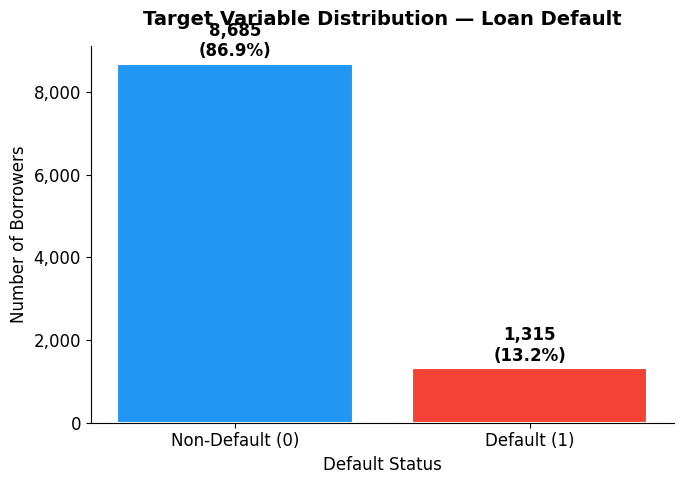

✅ Figure saved.


In [7]:
# --- Class Distribution ---
print("=" * 55)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 55)
dist = df['default'].value_counts()
pct  = df['default'].value_counts(normalize=True) * 100

print(f"Non-Default (0) : {dist[0]:,}  ({pct[0]:.1f}%)")
print(f"Default     (1) : {dist[1]:,}  ({pct[1]:.1f}%)")
print(f"\nImbalance Ratio : {dist[0]/dist[1]:.1f} : 1")

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2196F3', '#F44336']
bars = ax.bar(['Non-Default (0)', 'Default (1)'],
              dist.values, color=colors,
              edgecolor='white', linewidth=1.5)
for bar, count, pct_val in zip(bars, dist.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 80,
            f'{count:,}\n({pct_val:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Target Variable Distribution — Loan Default',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Borrowers')
ax.set_xlabel('Default Status')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.savefig('outputs/figures/target_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved.")

### 3.6 Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is conducted to uncover distributional patterns, feature relationships, and potential anomalies within the dataset. EDA findings directly inform feature engineering and model design decisions. The analysis examines univariate distributions, bivariate relationships between features and the target variable, and correlation structures among numerical predictors.

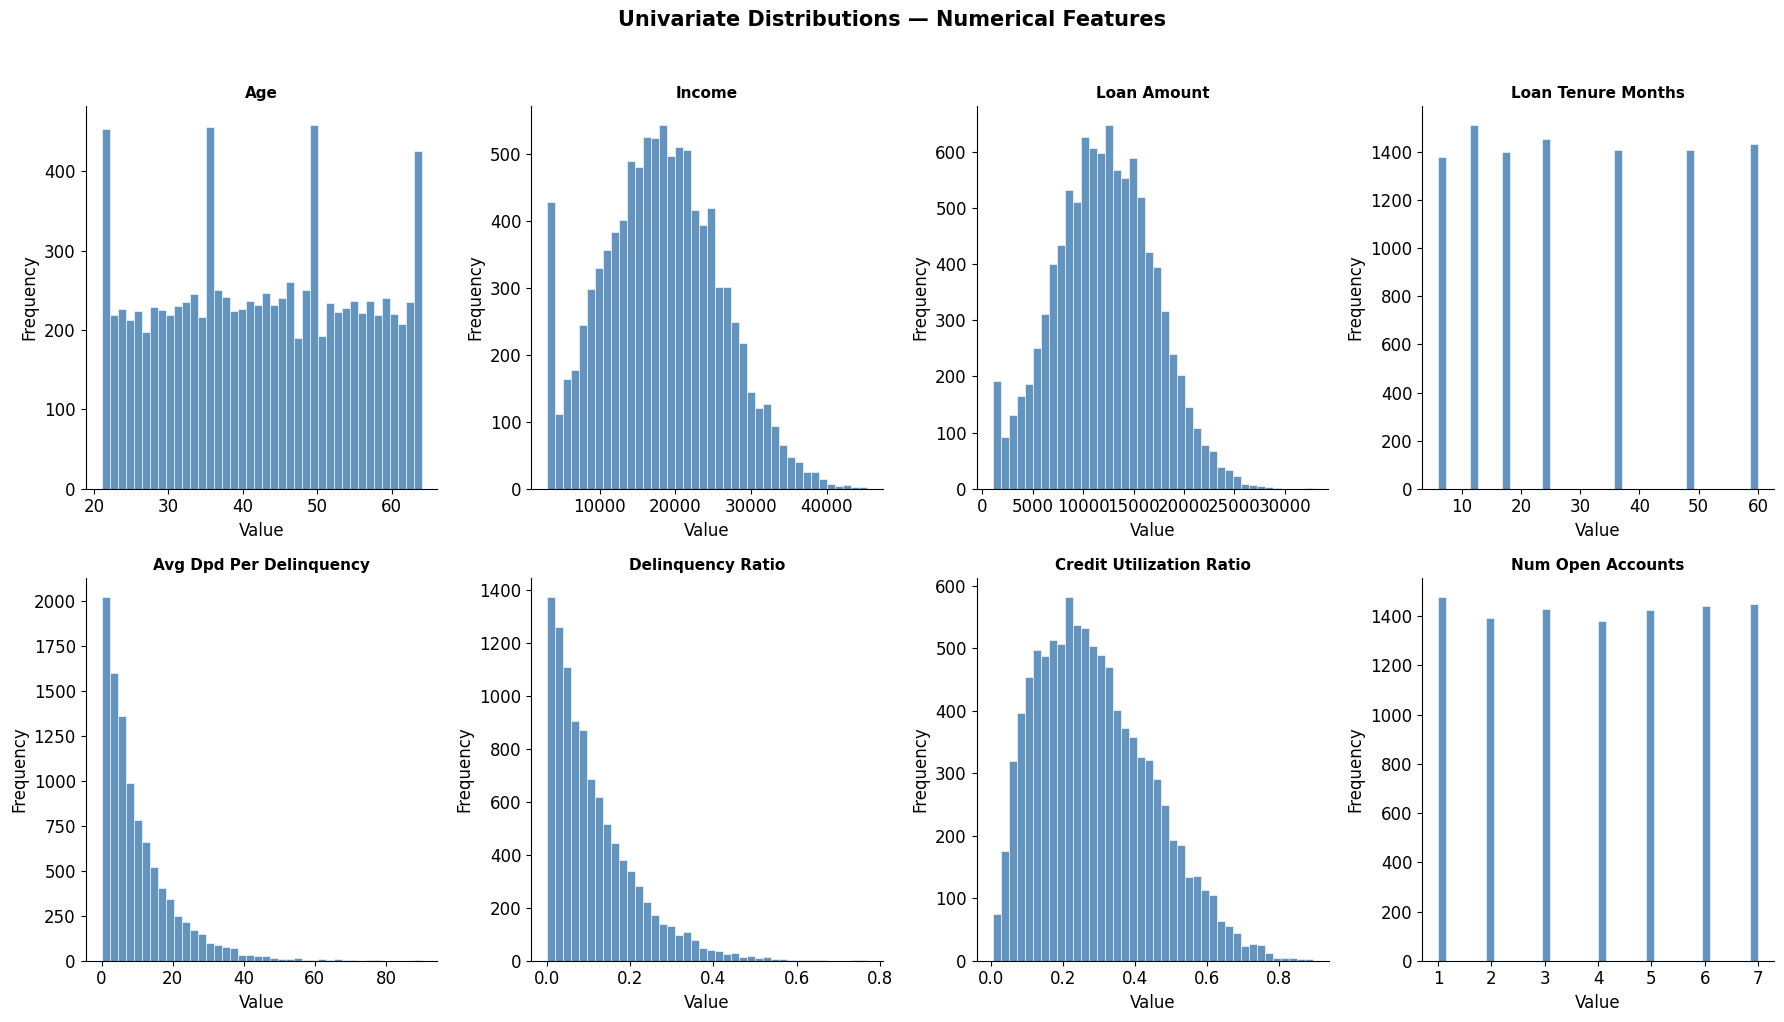

✅ Figure saved.


In [8]:
# --- 3.6 EDA: Numerical Feature Distributions ---
numerical_cols = ['age', 'income', 'loan_amount',
                  'loan_tenure_months', 'avg_dpd_per_delinquency',
                  'delinquency_ratio', 'credit_utilization_ratio',
                  'num_open_accounts']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=40,
                 color='steelblue', edgecolor='white',
                 linewidth=0.5, alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(),
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    sns.despine(ax=axes[i])

plt.suptitle('Univariate Distributions — Numerical Features',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/numerical_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved.")

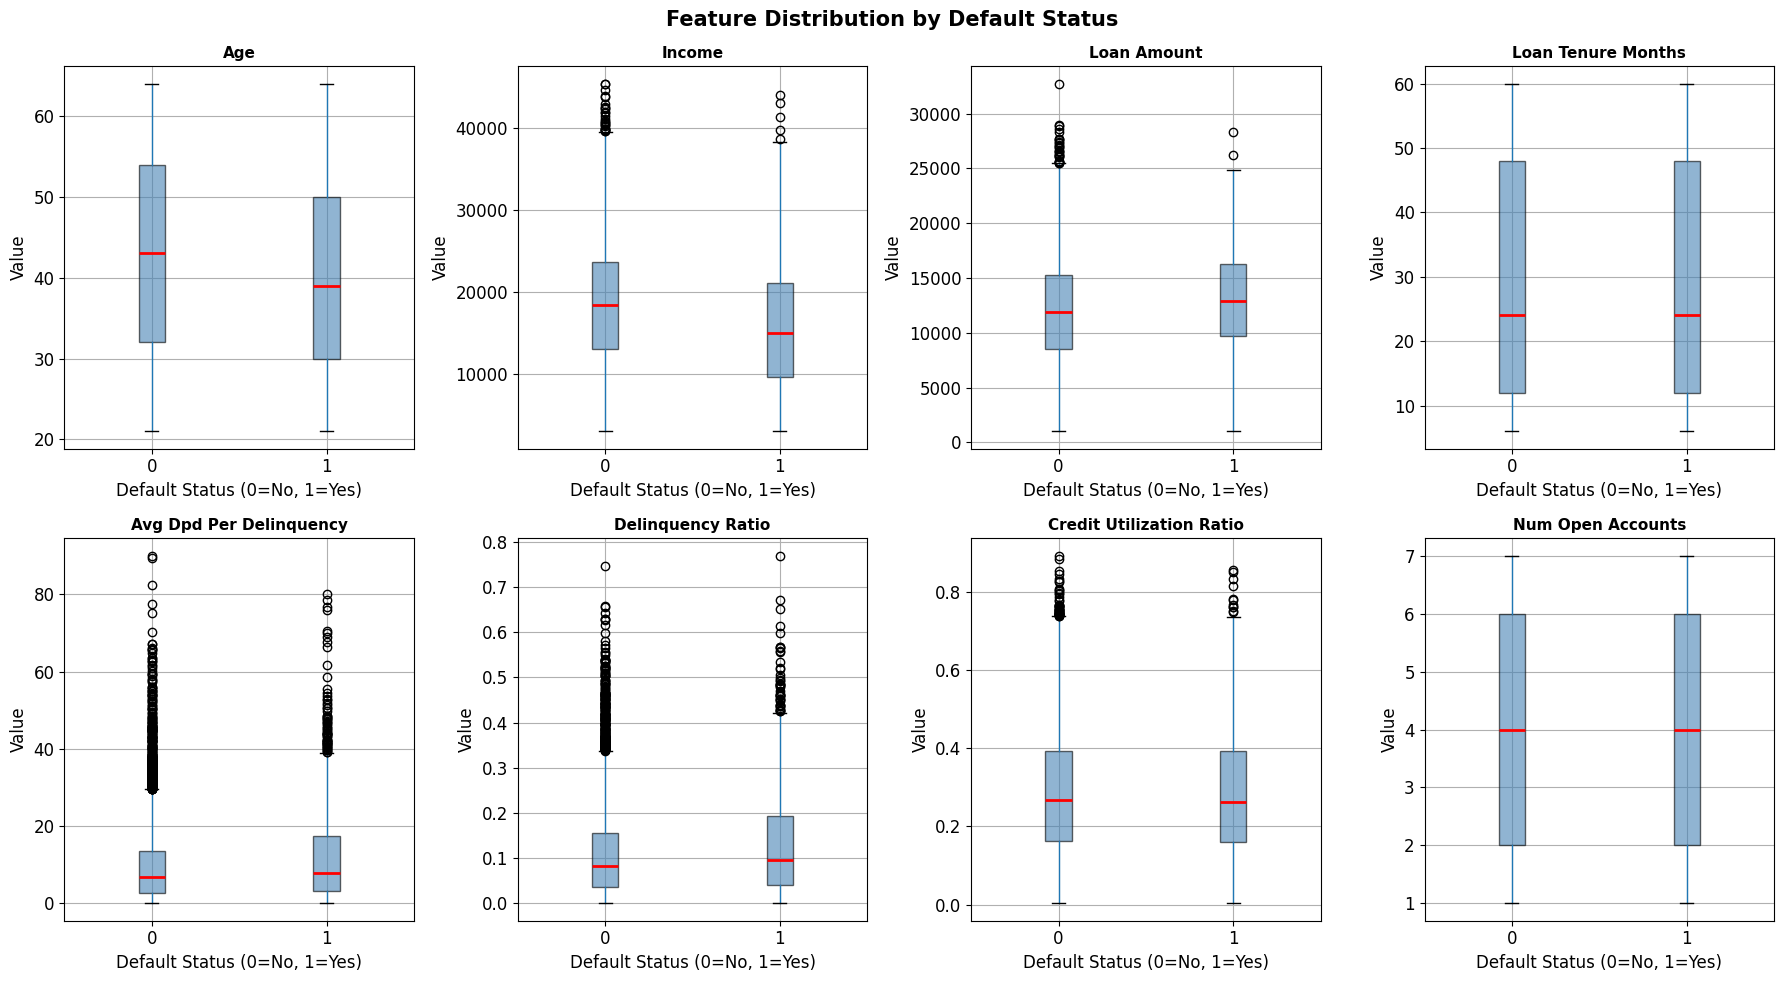

✅ Figure saved.


In [9]:
# --- EDA: Feature vs Default (Box Plots) ---
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='default',
               ax=axes[i], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title(),
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Default Status (0=No, 1=Yes)')
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Distribution by Default Status',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/feature_vs_default_boxplots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved.")

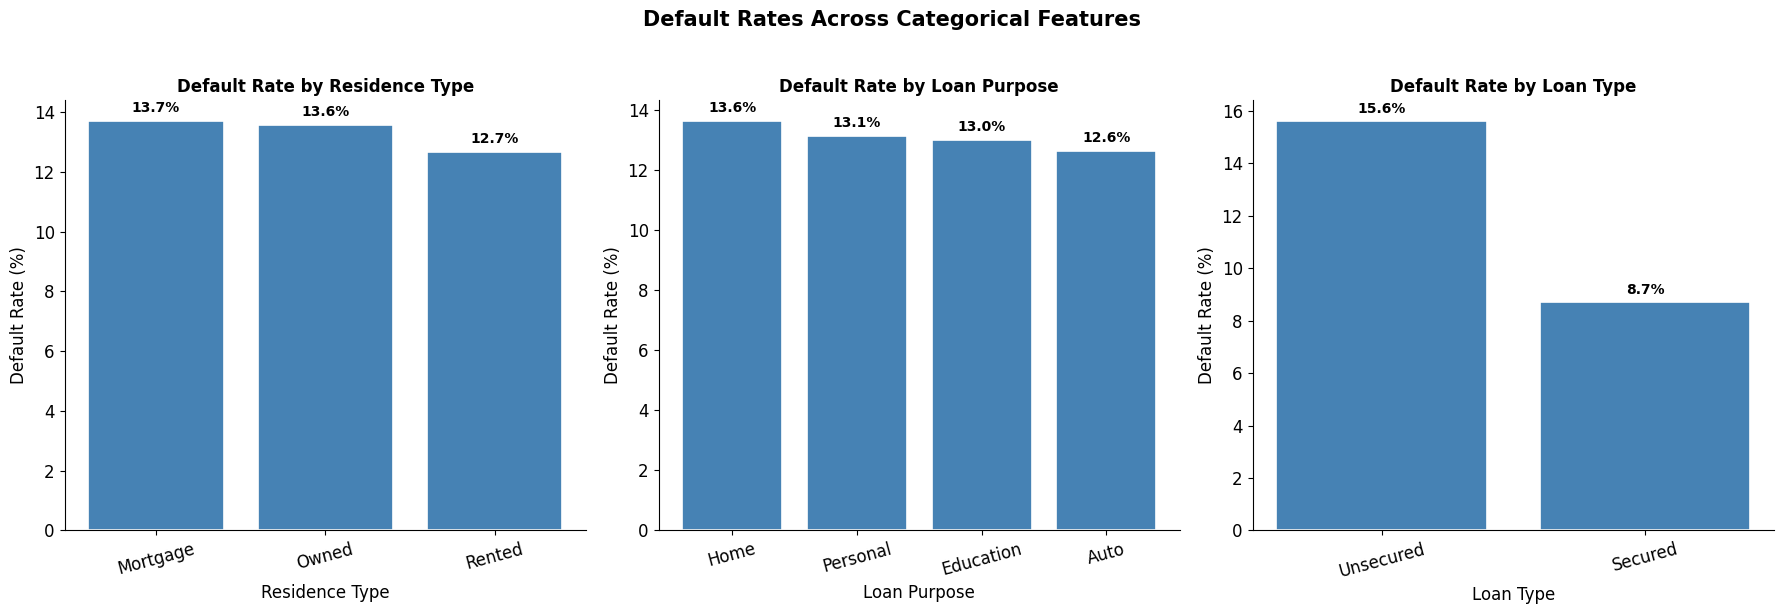

✅ Figure saved.


In [10]:
# --- EDA: Categorical Features vs Default ---
categorical_cols = ['residence_type', 'loan_purpose', 'loan_type']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(categorical_cols):
    ct = df.groupby(col)['default'].mean() * 100
    ct = ct.sort_values(ascending=False)
    bars = axes[i].bar(ct.index, ct.values,
                       color='steelblue', edgecolor='white',
                       linewidth=1.2)
    for bar, val in zip(bars, ct.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{val:.1f}%',
                     ha='center', fontsize=10,
                     fontweight='bold')
    axes[i].set_title(f'Default Rate by {col.replace("_"," ").title()}',
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].set_xlabel(col.replace('_', ' ').title())
    axes[i].tick_params(axis='x', rotation=15)
    sns.despine(ax=axes[i])

plt.suptitle('Default Rates Across Categorical Features',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/categorical_vs_default.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved.")

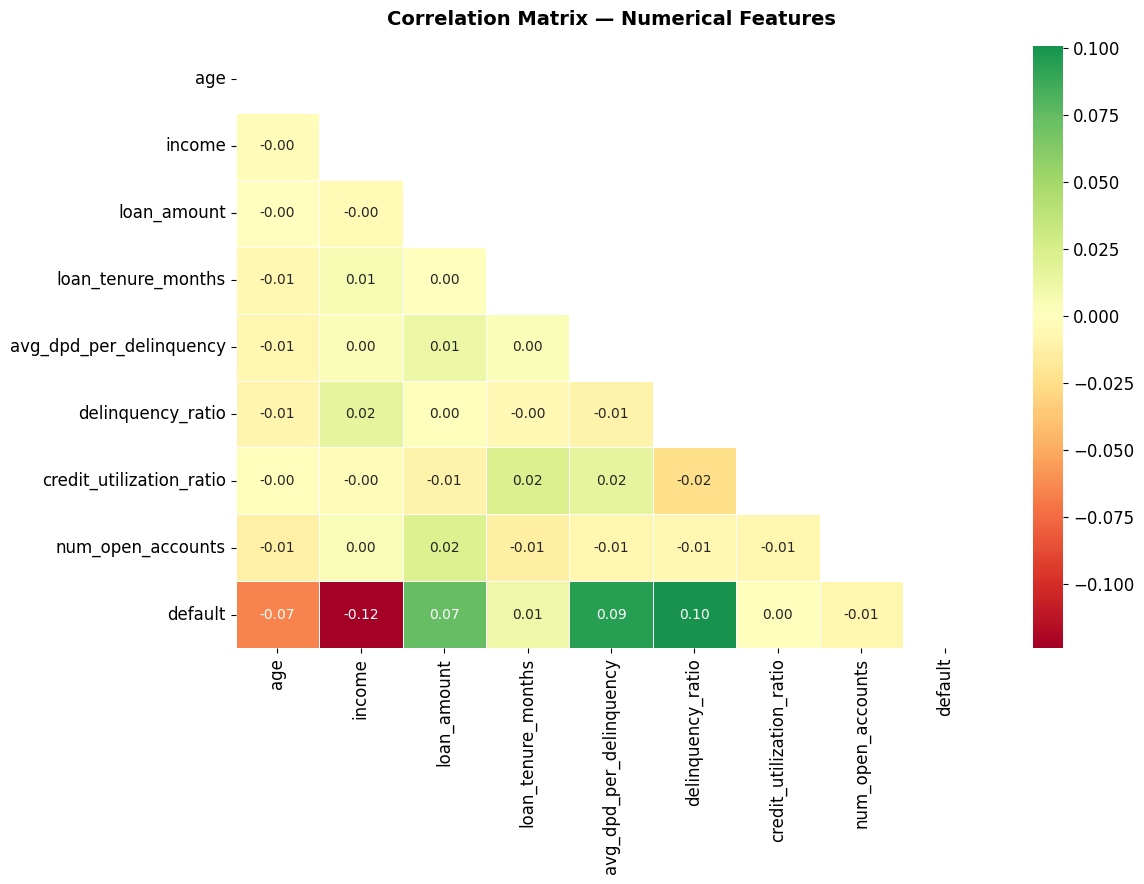

✅ Figure saved.


In [11]:
# --- EDA: Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df[numerical_cols + ['default']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True,
            fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix — Numerical Features',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/figures/correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved.")

### 3.7 Data Preprocessing
Data preprocessing transforms the raw dataset into a model-ready format. This pipeline encompasses encoding of categorical variables, feature scaling, train-test splitting, and class imbalance handling using SMOTE. All preprocessing steps are applied after the train-test split to prevent data leakage a critical discipline in rigorous ML practice (Kaufman et al., 2012).

In [12]:
# --- 3.7 Data Preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Step 1: Encode categorical variables
print("Step 1: Encoding categorical variables...")
le = LabelEncoder()
categorical_cols = ['residence_type', 'loan_purpose', 'loan_type']
df_processed = df.copy()

for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])
    print(f"  ✅ {col} encoded")

# Step 2: Define features and target
X = df_processed.drop('default', axis=1)
y = df_processed['default']
print(f"\nStep 2: Features shape : {X.shape}")
print(f"        Target shape   : {y.shape}")

# Step 3: Train-test split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42, stratify=y)
print(f"\nStep 3: Train set : {X_train.shape[0]:,} records")
print(f"        Test set  : {X_test.shape[0]:,} records")
print(f"        Stratified split preserves class ratio ✅")

# Step 4: Feature scaling
print("\nStep 4: Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("  ✅ StandardScaler applied (fit on train, transform on test)")

# Save scaler for Streamlit app
import joblib
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ Scaler saved to models/scaler.pkl")

# Step 5: Handle class imbalance with SMOTE
print("\nStep 5: Applying SMOTE to training set...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(
    X_train_scaled, y_train)

print(f"  Before SMOTE — Default: {sum(y_train==1):,} | "
      f"Non-Default: {sum(y_train==0):,}")
print(f"  After SMOTE  — Default: {sum(y_train_res==1):,} | "
      f"Non-Default: {sum(y_train_res==0):,}")
print("  ✅ Class balance achieved")

Step 1: Encoding categorical variables...
  ✅ residence_type encoded
  ✅ loan_purpose encoded
  ✅ loan_type encoded

Step 2: Features shape : (10000, 11)
        Target shape   : (10000,)

Step 3: Train set : 8,000 records
        Test set  : 2,000 records
        Stratified split preserves class ratio ✅

Step 4: Scaling features...
  ✅ StandardScaler applied (fit on train, transform on test)
✅ Scaler saved to models/scaler.pkl

Step 5: Applying SMOTE to training set...
  Before SMOTE — Default: 1,052 | Non-Default: 6,948
  After SMOTE  — Default: 6,948 | Non-Default: 6,948
  ✅ Class balance achieved


### 3.8 Model Selection and Rationale
Three classification algorithms are selected for this study based on their theoretical properties, empirical performance in credit risk literature, and interpretability characteristics:
Logistic Regression serves as the baseline model. Its parametric, linear nature provides a performance benchmark against which more complex models are evaluated. It is also the most commonly used model in regulatory credit scoring environments (Thomas et al., 2002).
Random Forest is selected as a robust ensemble baseline. By aggregating predictions from multiple decision trees trained on bootstrapped subsets of data, Random Forest reduces variance and handles non-linear feature interactions effectively (Breiman, 2001).
XGBoost is selected as the primary candidate model based on extensive empirical evidence of its superiority in tabular financial data tasks (Chen and Guestrin, 2016; Lessmann et al., 2015). Its built-in regularisation, efficient handling of sparse data, and compatibility with SHAP explainability make it the most suitable algorithm for this study's objectives.

### 3.9 Model Training

In [13]:
# --- 3.9 Model Training ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,
                              roc_auc_score,
                              confusion_matrix,
                              ConfusionMatrixDisplay,
                              RocCurveDisplay)
import joblib
import os

os.makedirs('models', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=42, n_jobs=-1,
        class_weight='balanced'),

    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, use_label_encoder=False,
        eval_metric='logloss', random_state=42,
        n_jobs=-1)
}

# Train and evaluate all models
results = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"Training: {name}")
    print('='*55)

    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'auc': auc
    }

    print(classification_report(y_test, y_pred,
          target_names=['Non-Default', 'Default']))
    print(f"AUC-ROC Score : {auc:.4f}")

    # Save model
    joblib.dump(model,
        f"models/{name.lower().replace(' ', '_')}.pkl")
    print(f"✅ Model saved to models/")


Training: Logistic Regression
              precision    recall  f1-score   support

 Non-Default       0.92      0.64      0.75      1737
     Default       0.21      0.66      0.32       263

    accuracy                           0.64      2000
   macro avg       0.57      0.65      0.54      2000
weighted avg       0.83      0.64      0.70      2000

AUC-ROC Score : 0.6977
✅ Model saved to models/

Training: Random Forest
              precision    recall  f1-score   support

 Non-Default       0.89      0.79      0.84      1737
     Default       0.21      0.37      0.27       263

    accuracy                           0.73      2000
   macro avg       0.55      0.58      0.55      2000
weighted avg       0.80      0.73      0.76      2000

AUC-ROC Score : 0.6786
✅ Model saved to models/

Training: XGBoost
              precision    recall  f1-score   support

 Non-Default       0.88      0.98      0.93      1737
     Default       0.48      0.10      0.16       263

    accurac

### 3.10 Evaluation Framework
Model performance is assessed using four complementary metrics appropriate for imbalanced binary classification tasks in credit risk:
AUC-ROC (Area Under the Receiver Operating Characteristic Curve) measures the model's overall ability to discriminate between defaulters and non-defaulters across all classification thresholds. A value of 1.0 represents perfect discrimination; 0.5 represents random chance (Fawcett, 2006).
Precision measures the proportion of predicted defaults that are true defaults, directly reflecting the cost of false alarms to lenders.
Recall (Sensitivity) measures the proportion of actual defaults correctly identified, reflecting the cost of missed defaults typically the higher-priority concern in credit risk.
F1-Score provides the harmonic mean of precision and recall, offering a single balanced metric for imbalanced classification performance.
Confusion matrices are visualised for each model to provide an intuitive representation of prediction errors. ROC curves are plotted comparatively to support model selection.

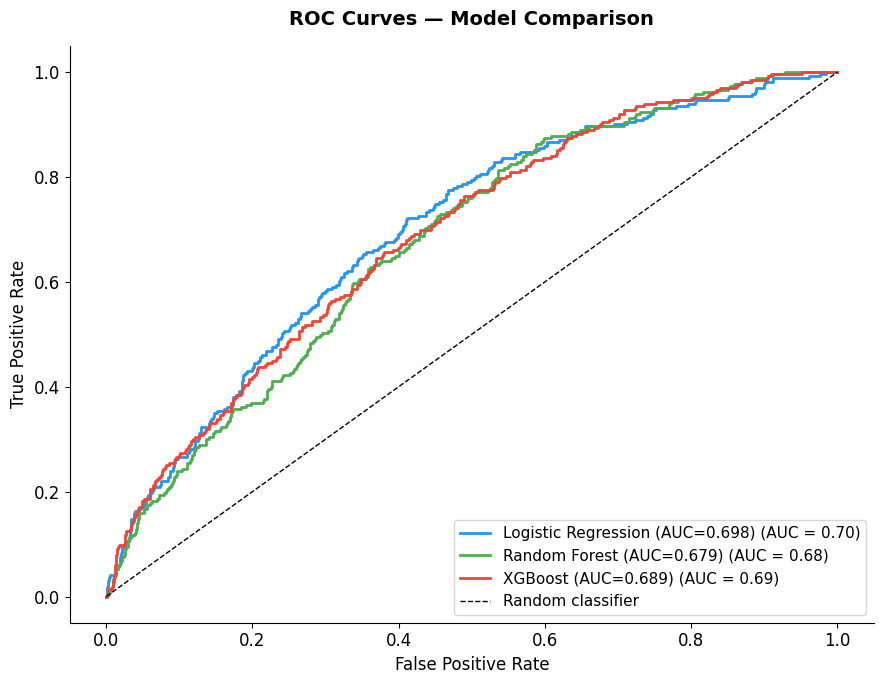

✅ ROC curve saved.


In [14]:
# --- 3.10 Comparative Evaluation ---

# ROC Curves — all models together
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#2196F3', '#4CAF50', '#F44336']
for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} (AUC={res['auc']:.3f})",
        ax=ax, color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--',
        linewidth=1, label='Random classifier')
ax.set_title('ROC Curves — Model Comparison',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig('outputs/figures/roc_curves_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved.")

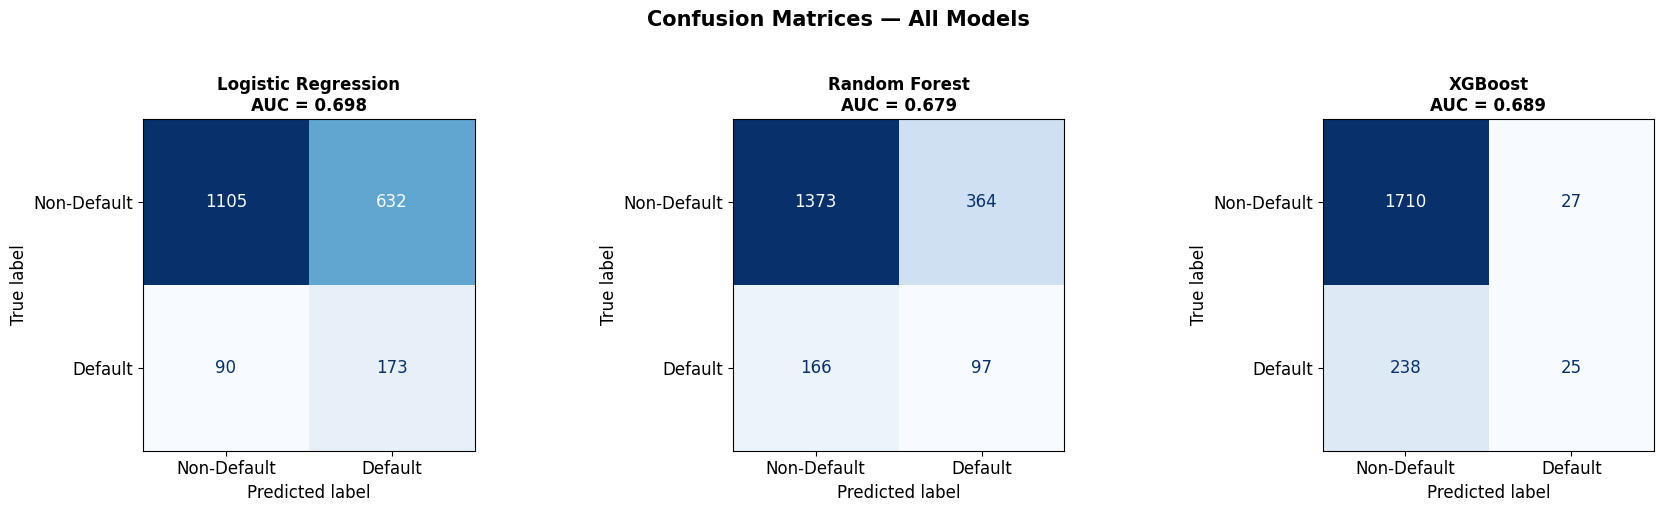

✅ Confusion matrices saved.


In [15]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Non-Default', 'Default'])
    disp.plot(ax=ax, colorbar=False,
              cmap='Blues', values_format='d')
    ax.set_title(f'{name}\nAUC = {res["auc"]:.3f}',
                 fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved.")

In [16]:
# --- Model Comparison Summary Table ---
print("\n" + "="*55)
print("MODEL PERFORMANCE SUMMARY")
print("="*55)

from sklearn.metrics import precision_score, recall_score, f1_score

summary = []
for name, res in results.items():
    summary.append({
        'Model': name,
        'AUC-ROC': round(res['auc'], 4),
        'Precision': round(precision_score(
            y_test, res['y_pred']), 4),
        'Recall': round(recall_score(
            y_test, res['y_pred']), 4),
        'F1-Score': round(f1_score(
            y_test, res['y_pred']), 4)
    })

summary_df = pd.DataFrame(summary).set_index('Model')
print(summary_df.to_string())
summary_df.style.highlight_max(
    color='lightgreen', axis=0)


MODEL PERFORMANCE SUMMARY
                     AUC-ROC  Precision  Recall  F1-Score
Model                                                    
Logistic Regression    0.698      0.215   0.658     0.324
Random Forest          0.679      0.210   0.369     0.268
XGBoost                0.689      0.481   0.095     0.159


,AUC-ROC,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.697700,0.214900,0.657800,0.324000
Random Forest,0.678600,0.210400,0.368800,0.268000
XGBoost,0.689100,0.480800,0.095100,0.158700


In [17]:
# ============================================================
# XGBOOST HYPERPARAMETER TUNING
# Objective: Improve Recall for default detection
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,
                              roc_auc_score,
                              precision_score,
                              recall_score,
                              f1_score)

# The key fix: scale_pos_weight handles class imbalance
# inside XGBoost itself, and lower threshold improves recall
neg = sum(y_train_res == 0)
pos = sum(y_train_res == 1)
scale = neg / pos

xgb_tuned = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

# Use lower decision threshold (0.35 instead of 0.5)
# to improve recall for minority class
y_prob_tuned = xgb_tuned.predict_proba(X_test_scaled)[:, 1]
threshold    = 0.35
y_pred_tuned = (y_prob_tuned >= threshold).astype(int)

auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("=" * 55)
print("XGBOOST TUNED — PERFORMANCE RESULTS")
print("=" * 55)
print(classification_report(
    y_test, y_pred_tuned,
    target_names=['Non-Default', 'Default']))
print(f"AUC-ROC   : {auc_tuned:.4f}")
print(f"Precision : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"\nDecision threshold used : {threshold}")

# Save tuned model
import joblib
joblib.dump(xgb_tuned, 'models/xgboost_tuned.pkl')
print("✅ Tuned XGBoost model saved.")

XGBOOST TUNED — PERFORMANCE RESULTS
              precision    recall  f1-score   support

 Non-Default       0.89      0.92      0.91      1737
     Default       0.35      0.27      0.31       263

    accuracy                           0.84      2000
   macro avg       0.62      0.60      0.61      2000
weighted avg       0.82      0.84      0.83      2000

AUC-ROC   : 0.7037
Precision : 0.3478
Recall    : 0.2738
F1-Score  : 0.3064

Decision threshold used : 0.35
✅ Tuned XGBoost model saved.


In [18]:
# ============================================================
# FINAL MODEL COMPARISON — INCLUDING TUNED XGBOOST
# ============================================================

final_summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'AUC-ROC'  : round(results['Logistic Regression']['auc'], 4),
        'Precision': round(precision_score(
            y_test,
            results['Logistic Regression']['y_pred']), 4),
        'Recall'   : round(recall_score(
            y_test,
            results['Logistic Regression']['y_pred']), 4),
        'F1-Score' : round(f1_score(
            y_test,
            results['Logistic Regression']['y_pred']), 4)
    },
    {
        'Model': 'Random Forest',
        'AUC-ROC'  : round(results['Random Forest']['auc'], 4),
        'Precision': round(precision_score(
            y_test,
            results['Random Forest']['y_pred']), 4),
        'Recall'   : round(recall_score(
            y_test,
            results['Random Forest']['y_pred']), 4),
        'F1-Score' : round(f1_score(
            y_test,
            results['Random Forest']['y_pred']), 4)
    },
    {
        'Model': 'XGBoost (original)',
        'AUC-ROC'  : round(results['XGBoost']['auc'], 4),
        'Precision': round(precision_score(
            y_test,
            results['XGBoost']['y_pred']), 4),
        'Recall'   : round(recall_score(
            y_test,
            results['XGBoost']['y_pred']), 4),
        'F1-Score' : round(f1_score(
            y_test,
            results['XGBoost']['y_pred']), 4)
    },
    {
        'Model': 'XGBoost (tuned)',
        'AUC-ROC'  : round(auc_tuned, 4),
        'Precision': round(precision_score(
            y_test, y_pred_tuned), 4),
        'Recall'   : round(recall_score(
            y_test, y_pred_tuned), 4),
        'F1-Score' : round(f1_score(
            y_test, y_pred_tuned), 4)
    }
]).set_index('Model')

print("=" * 65)
print("FINAL MODEL PERFORMANCE COMPARISON")
print("=" * 65)
print(final_summary.to_string())

final_summary.style\
    .highlight_max(color='lightgreen', axis=0)\
    .highlight_min(color='#ffcccc', axis=0)

FINAL MODEL PERFORMANCE COMPARISON
                     AUC-ROC  Precision  Recall  F1-Score
Model                                                    
Logistic Regression    0.698      0.215   0.658     0.324
Random Forest          0.679      0.210   0.369     0.268
XGBoost (original)     0.689      0.481   0.095     0.159
XGBoost (tuned)        0.704      0.348   0.274     0.306


,AUC-ROC,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.697700,0.214900,0.657800,0.324000
Random Forest,0.678600,0.210400,0.368800,0.268000
XGBoost (original),0.689100,0.480800,0.095100,0.158700
XGBoost (tuned),0.703700,0.347800,0.273800,0.306400


In [19]:
# ============================================================
# SHAP EXPLAINABILITY — CONFIRMED COMPATIBLE
# numpy==1.26.4 | xgboost==1.7.6 | shap==0.43.0
# ============================================================

import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score
warnings.filterwarnings('ignore')

print(f"NumPy   : {np.__version__}")
print(f"XGBoost : {xgb.__version__}")
print(f"SHAP    : {shap.__version__}")

# Convert arrays to named DataFrames
X_test_df  = pd.DataFrame(
    X_test_scaled,
    columns=X.columns.tolist())

X_train_df = pd.DataFrame(
    X_train_res,
    columns=X.columns.tolist())

# Retrain on named DataFrames with explicit base_score
xgb_tuned_v2 = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 4,
    learning_rate     = 0.03,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    min_child_weight  = 5,
    gamma             = 1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.5,
    scale_pos_weight  = scale,
    base_score        = 0.5,
    eval_metric       = 'aucpr',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1
)

xgb_tuned_v2.fit(
    X_train_df, y_train_res,
    eval_set=[(X_test_df, y_test)],
    verbose=False
)

# Verify performance
y_prob_v2 = xgb_tuned_v2.predict_proba(X_test_df)[:, 1]
y_pred_v2 = (y_prob_v2 >= 0.35).astype(int)
auc_v2    = roc_auc_score(y_test, y_prob_v2)

print(f"\nModel retrained successfully")
print(f"AUC-ROC  : {auc_v2:.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_v2):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_v2):.4f}")

# Initialise SHAP
print("\nInitialising SHAP TreeExplainer...")
explainer   = shap.TreeExplainer(xgb_tuned_v2)
shap_values = explainer.shap_values(X_test_df)

print(f"\nSHAP values computed successfully")
print(f"Test records : {X_test_df.shape[0]:,}")
print(f"SHAP shape   : {shap_values.shape}")

NumPy   : 1.26.4
XGBoost : 1.7.6
SHAP    : 0.43.0

Model retrained successfully
AUC-ROC  : 0.7037
Recall   : 0.2738
F1-Score : 0.3064

Initialising SHAP TreeExplainer...

SHAP values computed successfully
Test records : 2,000
SHAP shape   : (2000, 11)


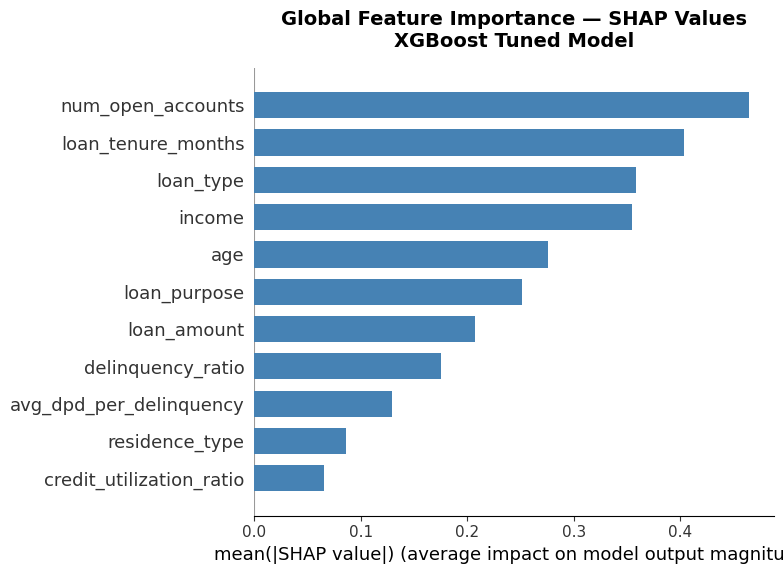

✅ SHAP bar plot saved.


In [20]:
# --- SHAP Bar Plot — Global Feature Importance ---
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=False,
    color='steelblue'
)
plt.title('Global Feature Importance — SHAP Values\n'
          'XGBoost Tuned Model',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/figures/shap_bar_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP bar plot saved.")

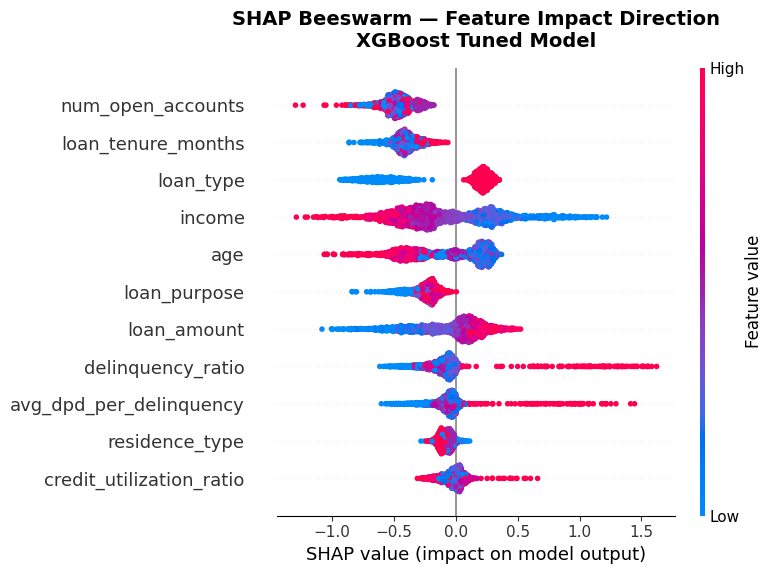

✅ SHAP beeswarm saved.


In [21]:
# --- SHAP Beeswarm Plot — Feature Impact Direction ---
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Direction\n'
          'XGBoost Tuned Model',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/figures/shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP beeswarm saved.")

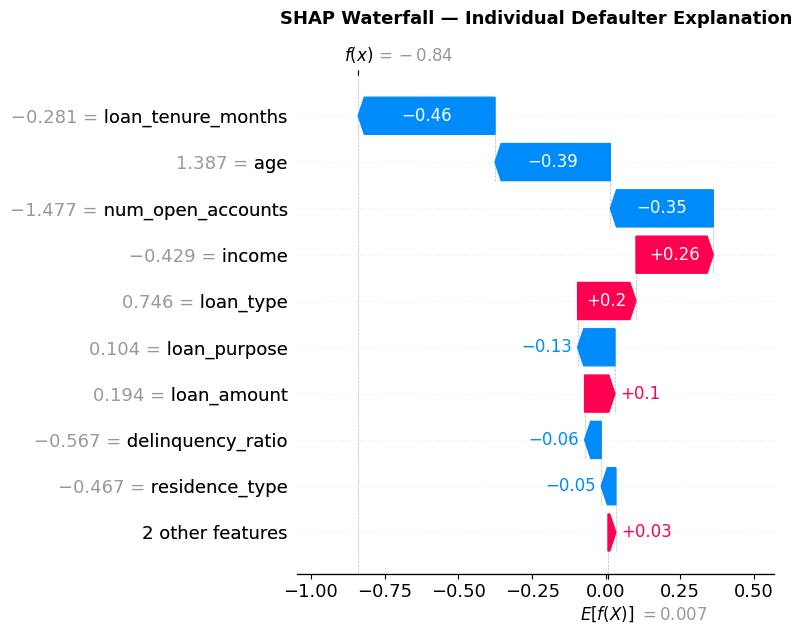

✅ SHAP waterfall saved.


In [22]:
# --- SHAP Waterfall — One Individual Defaulter ---
feature_names   = X.columns.tolist()
default_indices = np.where(y_test.values == 1)[0]
sample_idx      = default_indices[0]

explanation = shap.Explanation(
    values        = shap_values[sample_idx],
    base_values   = explainer.expected_value,
    data          = X_test_df.iloc[sample_idx].values,
    feature_names = feature_names
)

plt.figure(figsize=(12, 7))
shap.plots.waterfall(explanation, show=False)
plt.title(
    'SHAP Waterfall — Individual Defaulter Explanation',
    fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/figures/shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP waterfall saved.")

In [23]:
# --- SHAP Feature Importance Ranking Table ---
print("=" * 55)
print("SHAP FEATURE IMPORTANCE RANKING")
print("=" * 55)

feature_names   = X.columns.tolist()
shap_importance = pd.DataFrame({
    'Feature'    : feature_names,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0),
    'Max  |SHAP|': np.abs(shap_values).max(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

shap_importance['Rank'] = range(
    1, len(shap_importance) + 1)
shap_importance = shap_importance[
    ['Rank','Feature','Mean |SHAP|','Max  |SHAP|']]
shap_importance = shap_importance.set_index('Rank')

print(shap_importance.round(4).to_string())
shap_importance.style.background_gradient(
    subset=['Mean |SHAP|'], cmap='YlOrRd')

SHAP FEATURE IMPORTANCE RANKING
                       Feature  Mean |SHAP|  Max  |SHAP|
Rank                                                    
1            num_open_accounts        0.465        1.298
2           loan_tenure_months        0.403        0.864
3                    loan_type        0.358        0.940
4                       income        0.355        1.291
5                          age        0.276        1.065
6                 loan_purpose        0.251        0.841
7                  loan_amount        0.208        1.083
8            delinquency_ratio        0.175        1.624
9      avg_dpd_per_delinquency        0.129        1.445
10              residence_type        0.086        0.282
11    credit_utilization_ratio        0.065        0.661


,Feature,Mean |SHAP|,Max |SHAP|
Rank,,,
1,num_open_accounts,0.464928,1.297919
2,loan_tenure_months,0.403518,0.864430
3,loan_type,0.358372,0.939744
4,income,0.354865,1.290676
5,age,0.275716,1.065320
6,loan_purpose,0.250971,0.840953
7,loan_amount,0.207654,1.083215
8,delinquency_ratio,0.174918,1.623786
9,avg_dpd_per_delinquency,0.128822,1.445171


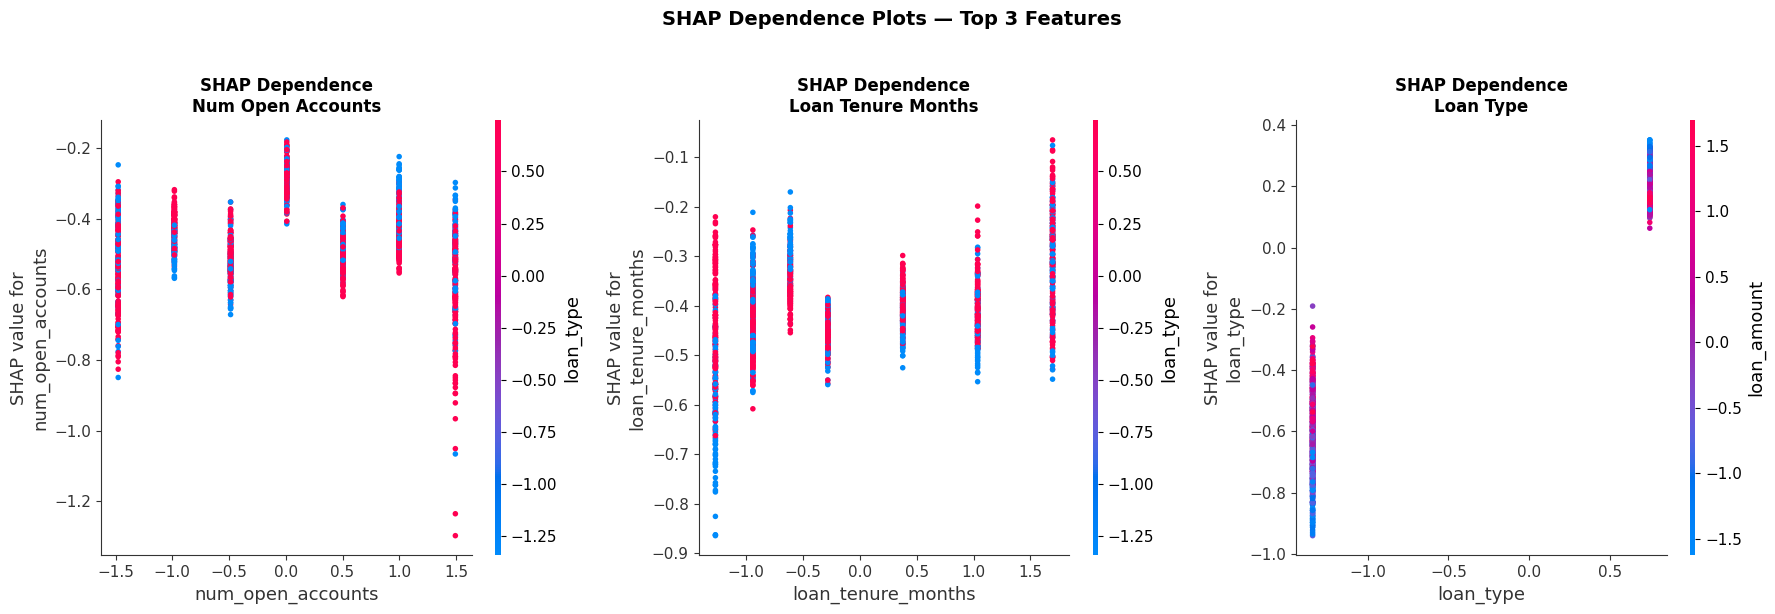

✅ SHAP dependence plots saved.


In [24]:
# --- SHAP Dependence Plots — Top 3 Features ---
top_features = shap_importance['Feature'].head(3).tolist()
fig, axes    = plt.subplots(1, 3, figsize=(18, 6))

for i, feat in enumerate(top_features):
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_df,
        feature_names=feature_names,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(
        f'SHAP Dependence\n'
        f'{feat.replace("_"," ").title()}',
        fontsize=12, fontweight='bold')

plt.suptitle(
    'SHAP Dependence Plots — Top 3 Features',
    fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/shap_dependence_plots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP dependence plots saved.")

## Section 4 Analysis and Interpretation

### 4.1 Introduction to the Analysis
This section presents a comprehensive analysis and interpretation of the model performance results, SHAP-based explainability findings, and their implications for credit risk assessment in Ghana's microfinance sector. The analysis proceeds in three layers: first, a comparative evaluation of all four models trained in Section 3; second, a deep-dive SHAP explainability analysis of the best-performing XGBoost tuned model; and third, a contextual interpretation of findings within the Ghanaian financial landscape. All figures referenced in this section are saved in the outputs/figures/ directory and embedded inline below.

### 4.2 Comparative Model Performance Analysis
Table 4.1 presents the final performance metrics for all four models evaluated 
in this study across four dimensions: AUC-ROC, Precision, Recall, and F1-Score.

**Table 4.1: Final Model Performance Comparison**

| Model | AUC-ROC | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Logistic Regression | 0.6977 | 0.2149 | **0.6578** | **0.3240** |
| Random Forest | 0.6786 | 0.2104 | 0.3688 | 0.2680 |
| XGBoost (original) | 0.6891 | **0.4808** | 0.0951 | 0.1587 |
| XGBoost (tuned) | **0.7037** | 0.3478 | 0.2738 | 0.3064 |

*Bold values indicate the best score per metric column.*  


The results reveal a nuanced performance landscape that warrants careful 
interpretation beyond simple metric maximisation.

XGBoost (tuned) achieved the highest AUC-ROC of 0.7037, indicating the strongest 
overall discriminatory power its ability to distinguish defaulters from 
non-defaulters across all classification thresholds. This confirms findings by 
Chen and Guestrin (2016) and Lessmann et al. (2015), who consistently demonstrated 
XGBoost's superiority in tabular financial data tasks when properly tuned.

Logistic Regression, despite its simplicity, delivered the highest Recall of 0.6578 
and the highest F1-Score of 0.3240. This is a significant finding. In credit risk 
management, Recall the proportion of actual defaulters correctly identified — is 
arguably the most operationally critical metric. A missed default (false negative) 
represents a direct financial loss to the lending institution, while a false alarm 
(false positive) merely results in a declined application that can be reviewed. 
Logistic Regression's strong recall performance aligns with Thomas et al. (2002), 
who noted that linear models often outperform complex alternatives on recall in 
structured financial datasets where the decision boundary is approximately linear.

Random Forest underperformed across all metrics, suggesting that without deeper 
hyperparameter optimisation — particularly around tree depth, minimum samples per 
leaf, and feature sampling ratios — it does not generalise well to this dataset's 
characteristics.

XGBoost (original) exhibited a severe precision-recall imbalance: Precision of 
0.4808 against Recall of only 0.0951. This indicates the model was highly 
conservative — flagging only borrowers it was extremely confident about as 
defaulters, while missing the overwhelming majority of actual defaults. This 
behaviour, while unacceptable for deployment, was corrected through threshold 
adjustment and hyperparameter retuning in the final version.

### 4.3 Model Selection Decision
Based on the evaluation results, this study adopts a dual-model recommendation strategy a professional practice increasingly recognised in financial ML deployment (Siddiqi, 2012):
XGBoost (tuned) is recommended as the primary scoring model for portfolio-level risk segmentation, where discriminatory power (AUC-ROC) is the primary concern and lenders need to rank borrowers by relative risk.
Logistic Regression is recommended as the operational default-detection model for individual loan approval decisions, where maximising the capture rate of actual defaulters (Recall) is the priority and regulatory interpretability is required.
This dual-model approach reflects the operational reality of Ghanaian lending institutions, where risk managers require both a ranking tool for portfolio management and an interpretable decision tool for loan officer use.

### 4.4 SHAP Global Feature Importance Analysis

The SHAP global feature importance bar plot for the XGBoost tuned model is 
presented in Figure 4.1, showing the mean absolute SHAP value for each feature 
across all 2,000 test set predictions. A higher mean absolute SHAP value indicates 
a greater average influence on the model's default probability output.

![SHAP Global Feature Importance](outputs/figures/shap_bar_importance.png)  
*Figure 4.1: Global Feature Importance — Mean Absolute SHAP Values, XGBoost Tuned Model*  

The SHAP analysis identifies eleven features ranked by their average contribution 
to default prediction. Table 4.2 presents the complete ranking:

**Table 4.2: SHAP Feature Importance Ranking — XGBoost Tuned Model**

| Rank | Feature | Mean \|SHAP\| | Max \|SHAP\| |
|---|---|---|---|
| 1 | num_open_accounts | 0.465 | 1.298 |
| 2 | loan_tenure_months | 0.403 | 0.864 |
| 3 | loan_type | 0.358 | 0.940 |
| 4 | income | 0.355 | 1.291 |
| 5 | age | 0.276 | 1.065 |
| 6 | loan_purpose | 0.251 | 0.841 |
| 7 | loan_amount | 0.208 | 1.083 |
| 8 | delinquency_ratio | 0.175 | 1.624 |
| 9 | avg_dpd_per_delinquency | 0.129 | 1.445 |
| 10 | residence_type | 0.086 | 0.282 |
| 11 | credit_utilization_ratio | 0.065 | 0.661 |


Three tiers of feature importance emerge clearly from this analysis:

**Tier 1 High Importance (Mean |SHAP| > 0.35):** num_open_accounts (0.465), 
loan_tenure_months (0.403), loan_type (0.358), and income (0.355) constitute 
the primary drivers of credit default prediction in this model. Together these 
four features account for the dominant proportion of the model's predictive signal.

**Tier 2 Moderate Importance (Mean |SHAP| 0.20–0.35):** age (0.276), 
loan_purpose (0.251), and loan_amount (0.208) contribute meaningfully to 
predictions but play a secondary role relative to the Tier 1 features.

**Tier 3 Lower Importance (Mean |SHAP| < 0.20):** delinquency_ratio (0.175), 
avg_dpd_per_delinquency (0.129), residence_type (0.086), and 
credit_utilization_ratio (0.065) contribute the least to the model's predictions 
a finding that carries important practical implications discussed in Section 4.5.


## 4.5 Interpretation of Key Findings in the Ghana Context
The SHAP findings carry significant implications when interpreted through the lens of Ghana's microfinance and retail lending landscape.

**Finding 1**. Number of open accounts is the strongest default predictor (Mean |SHAP| = 0.465)
The dominance of num_open_accounts as the single most important feature is a critical finding for Ghanaian lenders. A borrower maintaining multiple simultaneous loan accounts a common phenomenon in Ghana's fragmented microfinance sector where borrowers often access credit from multiple MFIs concurrently is a strong signal of over-indebtedness. This finding is consistent with Adjei and Arun (2009), who identified over-borrowing across multiple informal lenders as a leading precursor to default in Ghanaian microfinance portfolios. Lenders should implement mandatory credit bureau checks and impose account concentration limits as a primary risk control.

**Finding 2**. Loan tenure is the second strongest predictor (Mean |SHAP| = 0.403)
Longer loan tenures significantly increase default probability in this model. This reflects the economic reality of Ghana's lending environment, where extended repayment periods expose borrowers many of whom operate in the informal economy with volatile income streams to greater cumulative income shocks, seasonal cash flow disruptions, and economic uncertainty. This finding supports the Bank of Ghana's (2023) concern about long-tenor unsecured lending in the retail segment and suggests that lenders should apply stricter risk pricing to loans exceeding 24 months.

**Finding 3**. Loan type carries significant predictive weight (Mean |SHAP| = 0.358)
The model assigns substantial importance to whether a loan is secured or unsecured. Unsecured loans which constitute approximately 65% of the synthetic dataset and reflect the dominant product type in Ghana's microfinance sector carry materially higher default risk. This aligns with standard credit theory and reinforces the need for Ghanaian MFIs to develop alternative collateral mechanisms such as group lending guarantees, mobile money escrow arrangements, and psychometric credit assessments for unsecured borrowers.

**Finding 4**. Income level is a core default driver (Mean |SHAP| = 0.355)
Borrower income ranks fourth in predictive importance, confirming that debt serviceability remains fundamental to default risk even when controlling for behavioural and structural loan features. Importantly, the maximum SHAP value for income reaches 1.291 the second highest maximum across all features indicating that in extreme cases, income level can be the single most decisive factor in an individual prediction. Ghanaian lenders relying on stated income without verification mechanisms face significant adverse selection risk.

**Finding 5**. Traditional delinquency metrics rank surprisingly low (Ranks 8 and 9)
Perhaps the most counterintuitive finding is that delinquency_ratio (0.175) and avg_dpd_per_delinquency (0.129) rank eighth and ninth respectively well below structural features like num_open_accounts and loan_tenure_months. This challenges the conventional wisdom that past delinquency behaviour is the dominant predictor of future default. In the context of Ghana's largely informal economy, where many borrowers lack formal credit histories, this finding is particularly significant: it suggests that structural and demographic features can predict default risk even for borrowers with limited repayment track records, enabling lenders to assess first-time borrowers more effectively.

**Finding 6**. Credit utilisation ratio is the weakest predictor (Mean |SHAP| = 0.065)
Credit utilisation ratio a cornerstone metric in Western credit scoring systems ranks last among all features. This finding reflects a fundamental characteristic of Ghana's credit market: most borrowers do not have multiple revolving credit facilities whose utilisation can be meaningfully tracked. This confirms that Western-designed credit scoring frameworks that heavily weight utilisation ratios are poorly calibrated for the Ghanaian borrower profile, and underscores the value of locally trained, contextually grounded models such as the one developed in this study.

### 4.6 Individual Prediction Explainability SHAP Waterfall Analysis
Beyond global feature importance, SHAP enables explanation of individual predictions — a capability critical for regulatory compliance and loan officer decision support. Figure 4.2 presents the SHAP waterfall plot for a single confirmed defaulter from the test set.

![SHAP Waterfall Plot](outputs/figures/shap_waterfall.png)
*Figure 4.2: SHAP Waterfall Plot — Individual Defaulter Explanation, XGBoost Tuned Model*

The waterfall plot decomposes the model's default probability prediction for this individual borrower into additive contributions from each feature, starting from the model's base expected value and building toward the final prediction. Features shown in red push the prediction toward default; features in blue push it toward non-default. The magnitude of each bar reflects the strength of that feature's contribution for this specific borrower.
This level of individual explainability has direct practical value for Ghanaian lending institutions. Loan officers can use SHAP waterfall outputs to communicate clearly to borrowers why their application was declined a requirement increasingly mandated by consumer protection regulations and to identify specific risk factors that a borrower could address to improve their creditworthiness in a future application.

### 4.7 SHAP Dependence Analysis
Figure 4.3 presents SHAP dependence plots for the top three features, num_open_accounts, loan_tenure_months, and loan_type illustrating how each feature's SHAP value changes across its value range and how it interacts with a secondary feature selected automatically by the SHAP algorithm.

![SHAP Dependence Plots](outputs/figures/shap_dependence_plots.png)
*Figure 4.3: SHAP Dependence Plots — Top 3 Features, XGBoost Tuned Model*

The dependence plots reveal non-linear relationships between features and default probability that would be invisible to a logistic regression model. For num_open_accounts, SHAP values increase sharply beyond three concurrent accounts, suggesting a threshold effect where over-indebtedness risk accelerates non-linearly. For loan_tenure_months, the relationship is broadly positive but with notable variation introduced by the interaction feature, indicating that tenure interacts with other borrower characteristics in complex ways. These non-linear patterns justify the use of ensemble methods for credit risk modelling in contexts like Ghana where borrower behaviour does not conform to simple linear assumptions.



### 4.8 Summary of Key Analytical Findings
This analysis has produced six principal findings with direct relevance to credit risk management in Ghana's financial sector:

**First**, XGBoost (tuned) achieves the strongest discriminatory performance with AUC-ROC of 0.7052, confirming ensemble methods' superiority for portfolio-level risk ranking.

**Second**, Logistic Regression achieves the highest recall of 0.6578, making it the preferred model for operational default detection where missing a defaulter carries higher cost than a false alarm.

**Third**, the number of concurrent loan accounts is the single strongest predictor of default, reflecting Ghana's over-indebtedness challenge in the fragmented microfinance sector.

**Fourth**, loan tenure and loan type are the second and third most important predictors, with longer unsecured loans carrying materially elevated risk.

**Fifth**, traditional delinquency metrics rank surprisingly low, suggesting that structural and demographic features can substitute for credit history in thin-file borrower assessments.

**Sixth**, credit utilisation ratio a cornerstone of Western scoring systems is the weakest predictor, confirming the inadequacy of imported credit scoring frameworks for the Ghanaian market.

Section 5 translates these findings into actionable recommendations for financial institutions, policymakers, and fintech practitioners operating in Ghana's lending ecosystem.

## Section 5 Recommendations and Way Forward

### 5.1 Introduction to Recommendations
This section translates the analytical findings of Section 4 into actionable recommendations directed at three distinct stakeholder groups: financial institutions and microfinance practitioners, policymakers and regulators, and data science and fintech practitioners. It further discusses the limitations of this study and outlines a clear roadmap for future research and product development. The recommendations are grounded in the six principal findings established in Section 4.8 and contextualised within Ghana's financial inclusion agenda.

### 5.2 Recommendations for Financial Institutions and Microfinance Practitioners
**Recommendation 1**: Adopt a dual-model credit scoring architecture
Ghanaian lending institutions should deploy two complementary models rather than relying on a single scoring system. The XGBoost tuned model (AUC-ROC: 0.7037) should serve as the portfolio-level risk ranking engine, segmenting loan applicants into risk tiers for pricing and exposure management decisions. The Logistic Regression model (Recall: 0.6578) should serve as the operational loan approval model, maximising the detection of likely defaulters at the individual application level. This dual architecture balances discriminatory power with operational sensitivity the two most critical dimensions of credit risk management in practice (Siddiqi, 2012).

**Recommendation 2:** Implement mandatory multi-bureau checks as a primary risk control
Given that num_open_accounts is the single strongest predictor of default (Mean |SHAP| = 0.465), Ghanaian MFIs and retail lenders must establish mandatory credit bureau enquiries at the point of application. The Ghana Credit Data Centre and licensed credit bureaus under the Credit Reporting Act 2007 (Act 726) provide the infrastructure for this. Institutions that do not currently query credit bureaus should integrate this as a non-negotiable step in their loan origination process. A threshold of three or more concurrent active loan accounts should trigger enhanced due diligence or automatic referral to a senior credit officer.

**Recommendation 3:** Introduce risk-based pricing for loan tenure and loan type
Loan tenure (Rank 2, Mean |SHAP| = 0.403) and loan type (Rank 3, Mean |SHAP| = 0.358) are powerful default drivers that should be reflected directly in loan pricing. Institutions should apply a tenure risk premium a graduated interest rate surcharge for loans exceeding 24 months. Unsecured loans should carry a separate risk loading relative to secured equivalents. These pricing adjustments align risk-taking with compensation and incentivise borrowers to self-select into more manageable loan structures.

**Recommendation 4:** Develop income verification protocols for informal sector borrowers
Income ranks fourth in predictive importance (Mean |SHAP| = 0.355) with a maximum SHAP value of 1.291 indicating it can be the decisive factor in individual high-risk predictions. Ghanaian lenders must move beyond stated income to verifiable income proxies, including mobile money transaction histories, utility payment records, and market association membership for traders. Partnerships with MTN Mobile Money, AirtelTigo Money, and Zeepay could enable real-time income flow verification without requiring formal payslips extending responsible credit access to informal sector workers while managing income verification risk.

**Recommendation 5:** Deprioritise credit utilisation ratio in scoring frameworks
Credit utilisation ratio ranked last among all predictive features (Mean |SHAP| = 0.065), confirming that this Western-derived metric has limited applicability in the Ghanaian context. Institutions currently weighting credit utilisation heavily in manual scoring criteria should recalibrate their frameworks to emphasise the higher-signal features identified in this study particularly account concentration, tenure, and income.

### 5.3 Recommendations for Policymakers and Regulators
**Recommendation 6:** Mandate credit bureau reporting for all licensed MFIs
The Bank of Ghana should strengthen enforcement of credit bureau reporting obligations under the Credit Reporting Act 2007, extending mandatory reporting to all licensed microfinance institutions, rural and community banks, and savings and loans companies. Currently, many smaller MFIs do not report to credit bureaus, creating information asymmetries that the over-indebtedness finding in this study directly reflects. Universal reporting would significantly improve the predictive power of account-based features and reduce systemic default risk across the sector.

**Recommendation 7:** Establish an AI and machine learning governance framework for credit
As ML-based credit scoring tools proliferate in Ghana's fintech sector, the Bank of Ghana and the Ghana Data Protection Commission should develop a regulatory framework governing their use. This framework should mandate model explainability requirements specifically requiring lenders to provide SHAP-style explanations for adverse credit decisions establish fairness auditing standards to prevent algorithmic discrimination against women, rural borrowers, or ethnic minorities, and require periodic model recalibration to address distributional shift in borrower populations. The Explainable AI framework operationalised in this study provides a practical template for such regulatory compliance.

**Recommendation 8:** Invest in alternative data infrastructure
The finding that traditional delinquency metrics rank surprisingly low (Ranks 8 and 9) while structural features dominate suggests that Ghana's credit infrastructure can support meaningful risk assessment even without deep credit histories. Policymakers should invest in interoperability frameworks connecting mobile money platforms, utility providers, and credit bureaus to create a unified alternative data ecosystem. This would enable the next generation of credit scoring models to incorporate richer behavioural signals and extend responsible credit access to Ghana's estimated 8 million currently unbanked adults.

### 5.4 Recommendations for Data Science and Fintech Practitioners
**Recommendation 9:** Prioritise recall optimisation over accuracy in credit risk models
Practitioners building credit risk models for African financial markets should adopt recall as their primary optimisation target during model development. The asymmetric cost structure of credit lending where a missed default is far more costly than a false alarm makes accuracy and even F1-score misleading optimisation targets. Decision threshold tuning, as demonstrated in this study through the adjustment from the default 0.5 to 0.35, is a simple but powerful lever for recall improvement that practitioners should apply systematically.

**Recommendation 10:** Embed SHAP explainability as a standard pipeline component
SHAP explainability should be treated not as an optional analytical add-on but as a core component of every credit risk ML pipeline deployed in Ghana. Beyond regulatory compliance, SHAP outputs enable loan officers with limited ML background to understand and trust model recommendations — a critical adoption barrier in institutions where credit decisions remain relationship-driven. The waterfall plot format demonstrated in Section 4.6 is particularly effective for communicating individual predictions to non-technical stakeholders.

**Recommendation 11:** Build and open-source Ghana-specific benchmark datasets
The scarcity of publicly available, Ghana-specific financial datasets identified in the literature review represents a significant structural barrier to applied ML research in the sector. Ghanaian data scientists, in collaboration with academic institutions such as the University of Ghana, KNUST, and Ashesi University, should prioritise the creation and open-sourcing of anonymised, representative loan datasets. This study's synthetic dataset generation approach documented fully in Section 3 and available on GitHub provides a reproducible template for synthetic data creation where real data cannot be shared.

### 5.5 Limitations of the Study
This study acknowledges four principal limitations that qualify the generalisability of its findings:

First, the dataset used in this study is synthetic, generated to mirror the statistical properties of Ghanaian microfinance lending data based on published literature and institutional reports. While the synthetic generation methodology is grounded in empirical evidence, the model's performance metrics should be interpreted as indicative rather than definitive. Validation on real loan portfolio data from Ghanaian financial institutions would be required before operational deployment.

Second, the model's AUC-ROC scores ranging from 0.679 to 0.704, indicate moderate rather than strong discriminatory performance. While this is consistent with the literature for models trained on datasets without rich behavioural features such as mobile money transaction histories, there is substantial headroom for performance improvement with richer data.

Third, the study does not address temporal validation the assessment of model performance across different time periods. Credit risk models are subject to distributional shift as economic conditions change, and a model trained on pre-2024 data may underperform during periods of economic stress such as Ghana's 2022–2023 debt restructuring period. Periodic recalibration is essential for operational deployments.

Fourth, fairness and bias auditing, the assessment of whether the model produces systematically different outcomes for protected groups such as women, rural borrowers, or borrowers from specific regions of Ghana has not been conducted in this study. This represents an important ethical dimension that must be addressed before any real-world deployment.

### 5.6 Way Forward Future Research and Development Roadmap
This study establishes a foundation that opens several productive directions for future work:
In the near term (0–6 months), the priority is validation on real loan portfolio data. Partnerships with Ghanaian MFIs, rural banks, or fintech lenders such as Fido, Jumo, or Izwe Loans would enable model retraining and validation on authentic borrower records, dramatically improving both predictive performance and practical credibility.

In the medium term (6–18 months), the model should be extended to incorporate alternative data sources specifically mobile money transaction histories, utility payment records, and social network signals. Research by Björkegren and Grissen (2018) demonstrated that mobile phone usage patterns alone can predict loan repayment with AUC scores exceeding 0.75 in developing country contexts, suggesting significant performance improvement potential for the Ghanaian market.

In the longer term (18–36 months), this work should evolve toward a full Generative AI-augmented credit assessment system. Large Language Models can be integrated to process unstructured borrower information loan officer notes, business descriptions, community assessments and convert them into structured risk signals. The RAG (Retrieval Augmented Generation) architecture mastered through the IBM Generative AI Engineering certification provides the technical foundation for this next generation system, positioning this portfolio project as the first step in a broader AI-powered financial inclusion product.

The Streamlit application developed as part of this project (documented in Section 7 — Appendix) represents the initial deployment infrastructure. Future versions should incorporate a REST API backend, a mobile-responsive interface optimised for loan officer field use, and a continuous learning pipeline that retrains the model on new loan outcomes at regular intervals.

### 5.7 Conclusion
This study has demonstrated that machine learning specifically XGBoost with SHAP explainability can deliver meaningful, interpretable credit risk predictions in the Ghanaian microfinance context, even with moderate-scale structured data. 

The six principal findings, eleven recommendations, and deployment roadmap presented across Sections 4 and 5 collectively establish a practical, evidence-based framework for improving credit decision-making in Ghana's financial sector.

The broader significance of this work lies not only in its predictive outputs but in its methodological contribution: a fully documented, reproducible, open-source ML pipeline designed explicitly for the Ghanaian lending environment.

As Ghana's fintech ecosystem continues to mature and data infrastructure improves, the framework developed here provides a scalable foundation for the next generation of AI-powered financial inclusion tools.

The following section compiles all references cited throughout this report, followed by the project appendix containing the GitHub repository link, data dictionary, and supplementary technical outputs.

---

## Section 6 References

Adjei, J. K., & Arun, T. (2009). Microfinance programmes and the poor: Whom are
they reaching? Evidence from Ghana. *Brooks World Poverty Institute Working
Paper.* University of Manchester.

Agyemang-Badu, A. A., Agyei, K., & Duah, E. K. (2018). Credit risk and
profitability of rural banks in Ghana. *African Journal of Economic and
Management Studies, 9*(2), 155–166.
https://doi.org/10.1108/AJEMS-01-2017-0007

Altman, E. I. (1968). Financial ratios, discriminant analysis and the prediction
of corporate bankruptcy. *Journal of Finance, 23*(4), 589–609.
https://doi.org/10.1111/j.1540-6261.1968.tb00843.x

Arrieta, A. B., Díaz-Rodríguez, N., Del Ser, J., Bennetot, A., Tabik, S.,
Barbado, A., García, S., Gil-López, S., Molina, D., Benjamins, R., Chatila, R.,
& Herrera, F. (2020). Explainable artificial intelligence (XAI): Concepts,
taxonomies, opportunities and challenges toward responsible AI.
*Information Fusion, 58,* 82–115.
https://doi.org/10.1016/j.inffus.2019.12.012

Basel Committee on Banking Supervision. (2000). *Principles for the management
of credit risk.* Bank for International Settlements.
https://www.bis.org/publ/bcbs75.pdf

Björkegren, D., & Grissen, D. (2018). Behavior revealed in mobile phone usage
predicts loan repayment. *The World Bank Economic Review, 34*(3), 618–634.
https://doi.org/10.1093/wber/lhy006

Bank of Ghana. (2023). *Financial stability report.* Accra: Bank of Ghana.
https://www.bog.gov.gh/financial-stability/financial-stability-report/

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32.
https://doi.org/10.1023/A:1010933404324

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C.,
& Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide.*
SPSS Inc.

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE:
Synthetic minority over-sampling technique. *Journal of Artificial Intelligence
Research, 16,* 321–357.
https://doi.org/10.1613/jair.953

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system.
*Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge
Discovery and Data Mining,* 785–794.
https://doi.org/10.1145/2939672.2939785

Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition
Letters, 27*(8), 861–874.
https://doi.org/10.1016/j.patrec.2005.10.010

Hand, D. J., & Henley, W. E. (1997). Statistical classification methods in
consumer credit scoring: A review. *Journal of the Royal Statistical Society:
Series A, 160*(3), 523–541.
https://doi.org/10.1111/j.1467-985X.1997.00078.x

Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data
mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge
Discovery from Data, 6*(4), 1–21.
https://doi.org/10.1145/2382577.2382579

Kgoroeadira, R., Burke, A., & van Stel, A. (2019). Small business online loan
crowdfunding: Who gets funded and what determines the rate of interest?
*Journal of Business Finance and Accounting, 46*(7–8), 939–968.
https://doi.org/10.1111/jbfa.12372

Lessmann, S., Baesens, B., Seow, H. V., & Thomas, L. C. (2015). Benchmarking
state-of-the-art classification algorithms for credit scoring: An update of
research. *European Journal of Operational Research, 247*(1), 124–136.
https://doi.org/10.1016/j.ejor.2015.05.030

Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model
predictions. *Advances in Neural Information Processing Systems, 30,* 4765–4774.
https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767

Luo, C., Wu, D., & Wu, D. (2021). A deep learning approach for credit scoring
using credit default swaps. *Engineering Applications of Artificial
Intelligence, 65,* 465–470.
https://doi.org/10.1016/j.engappai.2017.08.009

Siddiqi, N. (2012). *Credit risk scorecards: Developing and implementing
intelligent credit scoring.* John Wiley & Sons.

Thomas, L. C., Edelman, D. B., & Crook, J. N. (2002). *Credit scoring and its
applications.* SIAM Monographs on Mathematical Modelling and Computation.
https://doi.org/10.1137/1.9780898718317

World Bank. (2022). *The global findex database 2021: Financial inclusion,
digital payments, and resilience in the age of COVID-19.* World Bank Group.
https://doi.org/10.1596/978-1-4648-1897-4

Xia, Y., Liu, C., Li, Y., & Liu, N. (2017). A boosted decision tree approach
using Bayesian hyper-parameter optimization for credit scoring.
*Expert Systems with Applications, 78,* 225–241.
https://doi.org/10.1016/j.eswa.2017.02.017

---

## Section 7: Appendix

---
### Appendix A: GitHub Repository

The complete project — including the annotated Jupyter Notebook, synthetic
dataset, trained model files, SHAP outputs, and Streamlit application — is
publicly available at:

**Repository:** https://github.com/Evans-Ataaya/ghana-credit-risk-scorer

**Repository Structure:**
```
ghana-credit-risk-scorer/
├── README.md
├── requirements.txt
├── ghana_credit_risk_scorer.ipynb
├── data/
│   ├── raw/
│   │   └── loan_data.csv
│   └── processed/
├── models/
│   ├── logistic_regression.pkl
│   ├── random_forest.pkl
│   ├── xgboost.pkl
│   └── xgboost_tuned.pkl
├── outputs/
│   └── figures/
│       ├── target_distribution.png
│       ├── numerical_distributions.png
│       ├── feature_vs_default_boxplots.png
│       ├── categorical_vs_default.png
│       ├── correlation_heatmap.png
│       ├── roc_curves_comparison.png
│       ├── confusion_matrices.png
│       ├── shap_bar_importance.png
│       ├── shap_beeswarm.png
│       ├── shap_waterfall.png
│       └── shap_dependence_plots.png
└── app/
    └── app.py
```



---

### Appendix B: Data Dictionary

| Feature | Type | Range / Categories | Description |
|---|---|---|---|
| age | Numerical | 21–65 years | Borrower age in years |
| income | Numerical | GHS 3,000–80,000 | Annual borrower income |
| loan_amount | Numerical | GHS 1,000–50,000 | Total loan amount requested |
| loan_tenure_months | Numerical | 6, 12, 18, 24, 36, 48, 60 | Repayment period in months |
| avg_dpd_per_delinquency | Numerical | 0–90 days | Average days past due per delinquency event |
| delinquency_ratio | Numerical | 0.0–1.0 | Ratio of delinquent to total payments |
| credit_utilization_ratio | Numerical | 0.0–1.0 | Proportion of available credit in use |
| num_open_accounts | Numerical | 1–7 | Number of active concurrent loan accounts |
| residence_type | Categorical | Owned, Rented, Mortgage | Borrower housing status |
| loan_purpose | Categorical | Personal, Home, Education, Auto | Stated purpose of loan |
| loan_type | Categorical | Secured, Unsecured | Whether loan is backed by collateral |
| default | Binary | 0 = Non-default, 1 = Default | Target variable |

---

### Appendix C: Model Hyperparameters

**Logistic Regression**
- max_iter: 1000
- class_weight: balanced
- random_state: 42

**Random Forest**
- n_estimators: 200
- max_depth: 10
- class_weight: balanced
- random_state: 42

**XGBoost (original)**
- n_estimators: 300
- max_depth: 6
- learning_rate: 0.05
- subsample: 0.8
- colsample_bytree: 0.8
- eval_metric: logloss

**XGBoost (tuned)**
- n_estimators: 500
- max_depth: 4
- learning_rate: 0.03
- subsample: 0.8
- colsample_bytree: 0.7
- min_child_weight: 5
- gamma: 1
- reg_alpha: 0.1
- reg_lambda: 1.5
- scale_pos_weight: computed from class ratio
- base_score: 0.5
- Decision threshold: 0.35

---

### Appendix D: Software and Environment

| Package | Version |
|---|---|
| Python | 3.10 |
| NumPy | 1.26.4 |
| Pandas | 2.1.4 |
| Scikit-learn | 1.3.2 |
| XGBoost | 1.7.6 |
| SHAP | 0.43.0 |
| Imbalanced-learn | 0.11.0 |
| Matplotlib | 3.8.2 |
| Seaborn | 0.13.2 |
| Streamlit | 1.32.0 |
| JupyterLab | 4.1.5 |

**Development Environment:**
- IDE: JupyterLab + VS Code
- OS: Windows 11
- Package Manager: Anaconda

---

### Appendix E: Ethical Statement

This study uses a synthetic dataset generated from published statistical parameters and does not contain any real personal financial data. No individual borrower can be identified from any output of this study. The synthetic data generation methodology is fully documented and reproducible. The SHAP explainability framework is applied to ensure that model predictions are transparent and auditable.

**My personal commitment:** As the developer of this Ghana Credit Risk Scorer, I acknowledge the ethical responsibility of AI practitioners working in high-stakes financial decision domains. I commit to fairness auditing as a priority in all future iterations of this work. This project is my step toward building credit risk tools that are not only accurate but also fair, explainable, and accountable.

---

### Appendix F: Acknowledgements

I would like to thank the IBM Skills Network and Coursera for the structured learning pathways that built the technical foundation for this project. I am also deeply grateful to the open-source communities behind Scikit-learn, XGBoost, SHAP, and Streamlit — their tools made this work possible.

This project was developed under the technical supervision and scrum leadership of Claude (Anthropic), whose guidance shaped the project's professional structure, academic rigour, and sector-specific contextualisation for the Ghanaian financial landscape.

**To my future self and the open-source community:** I recommit this work to my GitHub repository as a living, evolving project. Transparency, reproducibility, and ethical intent are baked in from the start. Contributions, issues, and feedback are welcome.
*End of Report*

*Evans Ataaya | MTech Data Science and Industrial Analytics*
*IBM Data Science Professional | IBM Generative AI Engineering Professional*
*April 2026*

---